PDS Exp 10 Project

Topic :- Diabetes Analysis and Prediction

Dataset :- PIMA dataset (Link :- https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database )

Group Members :- Swastik Shivane (2024800118)

Shlok Shinde (2024800116)

Varhun Singh (2024800121)

Smit Shah (2024800111)


Batch :- B3 B div CSE

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.model_selection as mod
import sklearn.neighbors as nei
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report, precision_recall_curve, average_precision_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import operator
%matplotlib inline

In [2]:
pima = pd.read_csv('diabetes.csv')

In [3]:
import pandas as pd
pima = pd.read_csv('diabetes.csv')
pima.columns = ['Preg', 'Gluc', 'BP', 'Skin', 'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']
description = {
    "Feature": pima.columns,
    "Data type": pima.dtypes.values,
    "Min": pima.min().values,
    "Max": pima.max().values
}
df_desc = pd.DataFrame(description)
print(df_desc)

   Feature Data type     Min     Max
,0     Preg     int64   0.000   17.00
,1     Gluc     int64   0.000  199.00
,2       BP     int64   0.000  122.00
,3     Skin     int64   0.000   99.00
,4  Insulin     int64   0.000  846.00
,5      BMI   float64   0.000   67.10
,6      DPF   float64   0.078    2.42
,7      Age     int64  21.000   81.00
,8  Outcome     int64   0.000    1.00


In [4]:
import pandas as pd
pima = pd.read_csv('diabetes.csv')
pima.columns = ['Preg', 'Gluc', 'BP', 'Skin', 'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']
summary = pima.describe().transpose()
print(summary[['min', '25%', '50%', 'mean', '75%', 'max']])

            min       25%       50%        mean        75%     max
,Preg      0.000   1.00000    3.0000    3.845052    6.00000   17.00
,Gluc      0.000  99.00000  117.0000  120.894531  140.25000  199.00
,BP        0.000  62.00000   72.0000   69.105469   80.00000  122.00
,Skin      0.000   0.00000   23.0000   20.536458   32.00000   99.00
,Insulin   0.000   0.00000   30.5000   79.799479  127.25000  846.00
,BMI       0.000  27.30000   32.0000   31.992578   36.60000   67.10
,DPF       0.078   0.24375    0.3725    0.471876    0.62625    2.42
,Age      21.000  24.00000   29.0000   33.240885   41.00000   81.00
,Outcome   0.000   0.00000    0.0000    0.348958    1.00000    1.00


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

pima = pd.read_csv('diabetes.csv')

def age_category(age):
    if age < 30: return 'Young'
    elif age < 50: return 'Middle-aged'
    else: return 'Senior'

pima['Age_Group'] = pima['Age'].apply(age_category)

le = LabelEncoder()
pima['Age_Group_Encoded'] = le.fit_transform(pima['Age_Group'])

print(pima[['Age_Group', 'Age_Group_Encoded']].head())

     Age_Group  Age_Group_Encoded
,0       Senior                  1
,1  Middle-aged                  0
,2  Middle-aged                  0
,3        Young                  2
,4  Middle-aged                  0


In [6]:
import pandas as pd

pima = pd.read_csv('diabetes.csv')

def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

pima['BMI_Class'] = pima['BMI'].apply(bmi_category)

pima_encoded = pd.get_dummies(pima, columns=['BMI_Class'], prefix='BMI')

print(pima_encoded.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
,0            6      148             72             35        0  33.6   
,1            1       85             66             29        0  26.6   
,2            8      183             64              0        0  23.3   
,3            1       89             66             23       94  28.1   
,4            0      137             40             35      168  43.1   
,
,   DiabetesPedigreeFunction  Age  Outcome  BMI_Normal  BMI_Obese  \
,0                     0.627   50        1       False       True   
,1                     0.351   31        0       False      False   
,2                     0.672   32        1        True      False   
,3                     0.167   21        0       False      False   
,4                     2.288   33        1       False       True   
,
,   BMI_Overweight  BMI_Underweight  
,0           False            False  
,1            True            False  
,2           False            F

In [7]:
pima.shape

(768, 10)

In [8]:
pima_row_idx = pima.index
pima_row_idx

RangeIndex(start=0, stop=768, step=1)

In [9]:
pima_col_idx = pima.columns
pima_col_idx

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Class'],
      dtype='object')

In [10]:
pima.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
BMI_Class                    object
dtype: object

In [11]:
pima.head (5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Class
0,6,148,72,35,0,33.6,0.627,50,1,Obese
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Normal
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obese


In [12]:
pima.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Class                   0
dtype: int64

In [13]:
Nutritional_status = pd.Series([])

In [14]:
for i in range(len(pima)):
    if pima['BMI'][i] == 0.0:
        Nutritional_status[i]="NA"

    elif pima['BMI'][i] < 18.5:
        Nutritional_status[i]="Underweight"

    elif pima['BMI'][i] < 25:
        Nutritional_status[i]="Normal"

    elif pima['BMI'][i] >= 25 and pima['BMI'][i] < 30:
        Nutritional_status[i]="Overweight"

    elif pima['BMI'][i] >= 30:
        Nutritional_status[i]="Obese"

    else:
        Nutritional_status[i]= pima['BMI'][i]

In [15]:
pima.insert(6, "Nutritional Status", Nutritional_status)

In [16]:
pima.head (5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Nutritional Status,DiabetesPedigreeFunction,Age,Outcome,BMI_Class
0,6,148,72,35,0,33.6,Obese,0.627,50,1,Obese
1,1,85,66,29,0,26.6,Overweight,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,Normal,0.672,32,1,Normal
3,1,89,66,23,94,28.1,Overweight,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,Obese,2.288,33,1,Obese


In [17]:
pima['Nutritional Status'].value_counts()

Nutritional Status
Obese          472
Overweight     179
Normal         102
NA              11
Underweight      4
Name: count, dtype: int64

11 women don't have information about BMI. Only 106 of 758 women have normal weight. Most of the women present overweight or obesity.

In [18]:
OGTT_Interpretation = pd.Series([])

In [19]:
for i in range(len(pima)):
    if pima['Glucose'][i] == 0.0:
        OGTT_Interpretation [i]="NA"

    elif pima['Glucose'][i] <= 140:
        OGTT_Interpretation [i]="Normal"

    elif pima['Glucose'][i] > 140 & pima['Glucose'][i] <= 198:
        OGTT_Interpretation [i]="Impaired Glucose Tolerance"

    elif pima['Glucose'][i] > 198:
        OGTT_Interpretation[i]="Diabetic Level"

    else:
        OGTT_Interpretation [i]= pima['Glucose'][i]

In [20]:
pima.insert(2, "Glucose Result", OGTT_Interpretation)

In [21]:
pima['Glucose Result'].value_counts()

Glucose Result
Normal                        571
Impaired Glucose Tolerance    192
NA                              5
Name: count, dtype: int64

Not a single individual from the sample showed OGTT result at "Diabetic levels". Would be interesting to calculate HOMA-IR to get information about insulin resistance of the sample.DISCUSS HERE ABOUT GLUCOSE INTOLERANCE AND INSULIN RESISTANCE

In [22]:
Impaired_Glucose_Tolerance_Diabetic = ((pima ['Glucose'] > 140 ) & (pima ['Glucose'] <= 198) & (pima ['Outcome'] == 1)).sum()
Impaired_Glucose_Tolerance_Diabetic

131

Not every women with impaired glucose tolerance have diabetes. That can show that the ones with impaired glucose tolerance might be in risk of developing diabetes or are diabetic, but not already diagnosed.

In [23]:
Normal_Glucose_Diabetic = ((pima ['Glucose'] != 0 ) & (pima ['Glucose'] <= 140) & (pima ['Outcome'] == 1)).sum()
Normal_Glucose_Diabetic

134

Half of the diabetic women showed normal glucose level. Information regarding drug therapy is needed.

In [24]:
Percentile_skin_thickness = pd.Series([])

In [25]:
pima['Age'].value_counts()

Age
22    72
21    63
25    48
24    46
23    38
28    35
26    33
27    32
29    29
31    24
41    22
30    21
37    19
42    18
33    17
38    16
36    16
32    16
45    15
34    14
46    13
43    13
40    13
39    12
35    10
50     8
51     8
52     8
44     8
58     7
47     6
54     6
49     5
48     5
57     5
53     5
60     5
66     4
63     4
62     4
55     4
67     3
56     3
59     3
65     3
69     2
61     2
72     1
81     1
64     1
70     1
68     1
Name: count, dtype: int64

In [26]:
for i in range(len(pima)):


    if pima["Age"][i] >= 20.0 and pima["Age"][i] <= 79.0:

        if pima["SkinThickness"][i] == 0.0:
            Percentile_skin_thickness[i]=" 0 NA"

        elif pima["SkinThickness"][i] < 11.9:
            Percentile_skin_thickness[i]="1 <P5th"

        elif pima["SkinThickness"][i] == 11.9:
            Percentile_skin_thickness[i]="2 P5th"

        elif pima["SkinThickness"][i] > 11.9 and pima["SkinThickness"][i] < 14.0:
            Percentile_skin_thickness[i]="3 P5th - P10th"

        elif pima["SkinThickness"][i] == 14.0:
            Percentile_skin_thickness[i]="4 P10th"

        elif pima["SkinThickness"][i] > 14.0 and  pima["SkinThickness"][i] < 15.8:
            Percentile_skin_thickness[i]="5 P10th - P15th"

        elif pima["SkinThickness"][i] == 15.8:
            Percentile_skin_thickness[i]="6 P15th"

        elif pima["SkinThickness"][i] > 15.8 and pima["SkinThickness"][i] < 18.0:
            Percentile_skin_thickness[i]="7 P15th - P25th"

        elif pima["SkinThickness"][i] == 18.0:
            Percentile_skin_thickness[i]="8 P25th"

        elif pima["SkinThickness"][i] > 18.0 and pima["SkinThickness"][i] < 23.5:
            Percentile_skin_thickness[i]="9 P25th - P50th"

        elif pima["SkinThickness"][i] == 23.5:
            Percentile_skin_thickness[i]="10 P50th"

        elif pima["SkinThickness"][i] > 23.5 and pima["SkinThickness"][i] < 29.0:
            Percentile_skin_thickness[i]="11 P50th - P75th"

        elif pima["SkinThickness"][i] == 29.0:
            Percentile_skin_thickness[i]="12 P75th"

        elif pima["SkinThickness"][i] > 29.0 and pima["SkinThickness"][i] < 31.9:
            Percentile_skin_thickness[i]="13 P75th - P85th"

        elif pima["SkinThickness"][i] == 31.9:
            Percentile_skin_thickness[i]="14 P85th"

        elif pima["SkinThickness"][i] > 31.9 and pima["SkinThickness"][i] < 33.7:
            Percentile_skin_thickness[i]="15 P85th - P90th"

        elif pima["SkinThickness"][i] == 33.7:
            Percentile_skin_thickness[i]="16 P90th"

        elif pima["SkinThickness"][i] > 33.7 and pima["SkinThickness"][i] < 35.9:
            Percentile_skin_thickness[i]="17 P90th - P95th"

        elif pima["SkinThickness"][i] == 35.9:
            Percentile_skin_thickness[i]="18 P95th"

        elif pima["SkinThickness"][i] > 35.9:
            Percentile_skin_thickness[i]="19 >P95th"

    elif pima["Age"][i] >= 80.0:  #Only 1 woman is 81 years old
        if  pima["SkinThickness"][i] > 31.7:
            Percentile_skin_thickness[i]="20 >P95th"

In [27]:
pima.insert(4, "Percentile skin thickness", Percentile_skin_thickness)

In [28]:
pima.head(5)

,Pregnancies,Glucose,Glucose Result,BloodPressure,Percentile skin thickness,SkinThickness,Insulin,BMI,Nutritional Status,DiabetesPedigreeFunction,Age,Outcome,BMI_Class
0,6,148,Impaired Glucose Tolerance,72,17 P90th - P95th,35,0,33.6,Obese,0.627,50,1,Obese
1,1,85,Normal,66,12 P75th,29,0,26.6,Overweight,0.351,31,0,Overweight
2,8,183,Impaired Glucose Tolerance,64,0 NA,0,0,23.3,Normal,0.672,32,1,Normal
3,1,89,Normal,66,9 P25th - P50th,23,94,28.1,Overweight,0.167,21,0,Overweight
4,0,137,Normal,40,17 P90th - P95th,35,168,43.1,Obese,2.288,33,1,Obese


In [29]:
pima['Percentile skin thickness'].value_counts()

Percentile skin thickness
 0 NA               227
19 >P95th           145
11 P50th - P75th     87
9 P25th - P50th      79
15 P85th - P90th     50
13 P75th - P85th     46
17 P90th - P95th     23
8 P25th              20
7 P15th - P25th      20
3 P5th - P10th       18
12 P75th             17
1 <P5th              15
5 P10th - P15th      14
4 P10th               6
20 >P95th             1
Name: count, dtype: int64

227 women don't have information regarding skin fold. Most of the sample have Percentile of skin thickness greater than 95th. 53 women had value below P15 indicating that they might be malnourished. Only one woman is 80 years old or older and she presents a Percentile of skin thickness greater than 95th.

In [30]:
diabetic_malnourished_st = ((pima ['SkinThickness'] < 15.8) & (pima ['Outcome'] == 1)).sum()
diabetic_malnourished_st

94

In [31]:
diabetic_malnourished_bmi = ((pima ['BMI'] < 18.5) & (pima ['Outcome'] == 1)).sum()
diabetic_malnourished_bmi

2

In [32]:
diabetic_malnourished_bmi_st = ((pima ['BMI'] < 18.5) & (pima ['SkinThickness'] < 15.8) & (pima ['Outcome'] == 1)).sum()
diabetic_malnourished_bmi_st

2

Interesting to note that 94 diabetic women were classified as underweight/malnourished based only on Skin thickness, but only 2 diabetic women presented underweight/malnutrition when considering BMI or BMI & Skin Thickness. Skinfold thicknesses are difficult measurements to make with precision and accuracy without rigorous training, for that reason they are rarely used today and not universally applicable. Besides, skinfold thickness can be problematic to identify malnutrition in many individuals as they vary with diseases such as diabetes, menopause, and hydrational status. That way, more data should be included in this dataset to help to identify malnutrition using skinfold thickness measurement.


In [33]:
pima.max()

Pregnancies                               17
Glucose                                  199
Glucose Result                        Normal
BloodPressure                            122
Percentile skin thickness    9 P25th - P50th
SkinThickness                             99
Insulin                                  846
BMI                                     67.1
Nutritional Status               Underweight
DiabetesPedigreeFunction                2.42
Age                                       81
Outcome                                    1
BMI_Class                        Underweight
dtype: object

In [34]:
#Check if the sample were classified as Underweight presented a BMI lower than 18.5

pima_underweight = pima[pima['Nutritional Status'] =='Underweight']
pima_underweight

,Pregnancies,Glucose,Glucose Result,BloodPressure,Percentile skin thickness,SkinThickness,Insulin,BMI,Nutritional Status,DiabetesPedigreeFunction,Age,Outcome,BMI_Class
239,0,104,Normal,76,0 NA,0,0,18.4,Underweight,0.582,27,0,Underweight
418,1,83,Normal,68,0 NA,0,0,18.2,Underweight,0.624,27,0,Underweight
438,1,97,Normal,70,5 P10th - P15th,15,0,18.2,Underweight,0.147,21,0,Underweight
526,1,97,Normal,64,9 P25th - P50th,19,82,18.2,Underweight,0.299,21,0,Underweight


In [35]:
pima['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

500 are not diabetic , 268 are diabetic

In [36]:
pima.groupby('Outcome').mean(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [37]:
pima.mean(numeric_only=True)

Pregnancies                   3.845052
Glucose                     120.894531
BloodPressure                69.105469
SkinThickness                20.536458
Insulin                      79.799479
BMI                          31.992578
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64

In [38]:
pima_glucose = pima.loc[pima['Glucose'] != 0]

In [39]:
pima_glucose.shape

(763, 13)

Glucose is an important factor in calculation of diabetic pedigree. Here , out of 768 women only 5 women do not have information about their glucose levels

In [40]:
pima_glucose['Glucose'].mean()

121.6867627785059

In [41]:
print(pima_glucose['Glucose'].min())
pima_glucose['Glucose'].max()

44


199

In [42]:
pima_BloodPressure = pima.loc[pima['BloodPressure'] != 0]
pima_BloodPressure.shape

(733, 13)

In [43]:
print(pima_BloodPressure['BloodPressure'].mean())
print(pima_BloodPressure['BloodPressure'].min())
pima_BloodPressure['BloodPressure'].max()

72.40518417462484
,24


122

35 women don't have information about Blood Pressure as the result shows 733 rows. The maximum value of Diastolic Blood Pressure shows that there are a possibility of some women to have hypertension (>90 mmHg) as it can be diagnosed when the blood pressure is 140/90 mmHg or higher (NICE, 2019). Diabetic individuals should be treated to Diastolic blood pressure goal of less than 90 mmHg. It is recommended that blood pressure should be measured at least annually in an adult with type 2 diabetes without previously diagnosed hypertension or renal disease (NICE, 2019). Systolic Blood Pressure measure should have been included in this dataset as studies show that blood pressure equal or greater than 115/75 mmHg is associated with increased rates of several diseases, including heart failure, kidney disease and mortality (BOER et al, 2017). Looking at the minimum value of Diastolic Blood Pressure (24 mmHg) it is totally out of the normal range even when the heart is 'relaxing' (between 40 to 160 mmHg). Individual with Diastolic blood pressure less or equal to 60 mmHg has low blood pressure (BLOOD PRESSURE UK).

In [44]:
pima_insulin = pima.loc[pima['Insulin'] != 0]
print(pima_insulin.shape)
print(pima_insulin['Insulin'].mean())
print(pima_insulin['Insulin'].min())
pima_insulin['Insulin'].max()

(394, 13)
,155.5482233502538
,14


846

Normal range of 2h insulin is from 16 to 166 mIU/L. The average value of 2h insulin of the samples show a normal range. However, some women of the sample seem to present high level of insulin level. It might be due obesity, early stage of T2DM or excessive insulin administration.

In [45]:
pima_BMI = pima.loc[pima['BMI'] != 0]
print(pima_BMI.shape)
print(pima_BMI['BMI'].mean())
print(pima_BMI['BMI'].min())
pima_BMI['BMI'].max()

(757, 13)
,32.457463672391015
,18.2


67.1

The minimum value of BMI shows that there is no case of underweight, but the maximum value shows cases of women with morbid obesity (BMI >= 40kg/m2). On an average , (BMI > 30kg/m2) , women here fall under obese category

In [46]:
pima_all = pima.loc[(pima['BMI'] != 0) & (pima['Insulin'] != 0) & (pima['BloodPressure'] != 0) & (pima['Glucose'] != 0)]

In [47]:
pima_all.shape

(392, 13)

Only 392 women have information about all the attributes. That number represents less than half of the sample (around 49% of the women of the sample have all information of all attributes).

In [48]:
 pima_all['Outcome'].value_counts()

Outcome
0    262
1    130
Name: count, dtype: int64

262 women do not have diabetes whereas 130 have

In [49]:
pima_all.groupby('Outcome').mean(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,2.721374,111.431298,68.969466,27.251908,130.854962,31.750763,0.472168,28.347328
1,4.469231,145.192308,74.076923,32.961538,206.846154,35.777692,0.625585,35.938462


Diabetic women tend to have higher number of pregnancies, higher level of glucose, higher Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function and Age. Both groups present BMI that indicates obesity. Women that have Diabetes have an average of insulin that is higher than the normal range (16 - 166 mIU/L). Both groups have average of glucose higher than the normal range (<= 100 mg/dL). It might indicate that some non diabetic women are in risk of have Diabetes in the future, specially the ones with higher levels of insulin (that might have insulin resistance).

In [50]:
diabetic_malnourished = ((pima_all ['SkinThickness'] < 15.8) & (pima_all ['Outcome'] == 1)).sum()
print(diabetic_malnourished)
diabetic_overweight_obese = ((pima_all ['BMI'] <= 30) & (pima_all ['Outcome'] == 1)).sum()
print(diabetic_overweight_obese)

4
,20


**_________________________________________________________________**

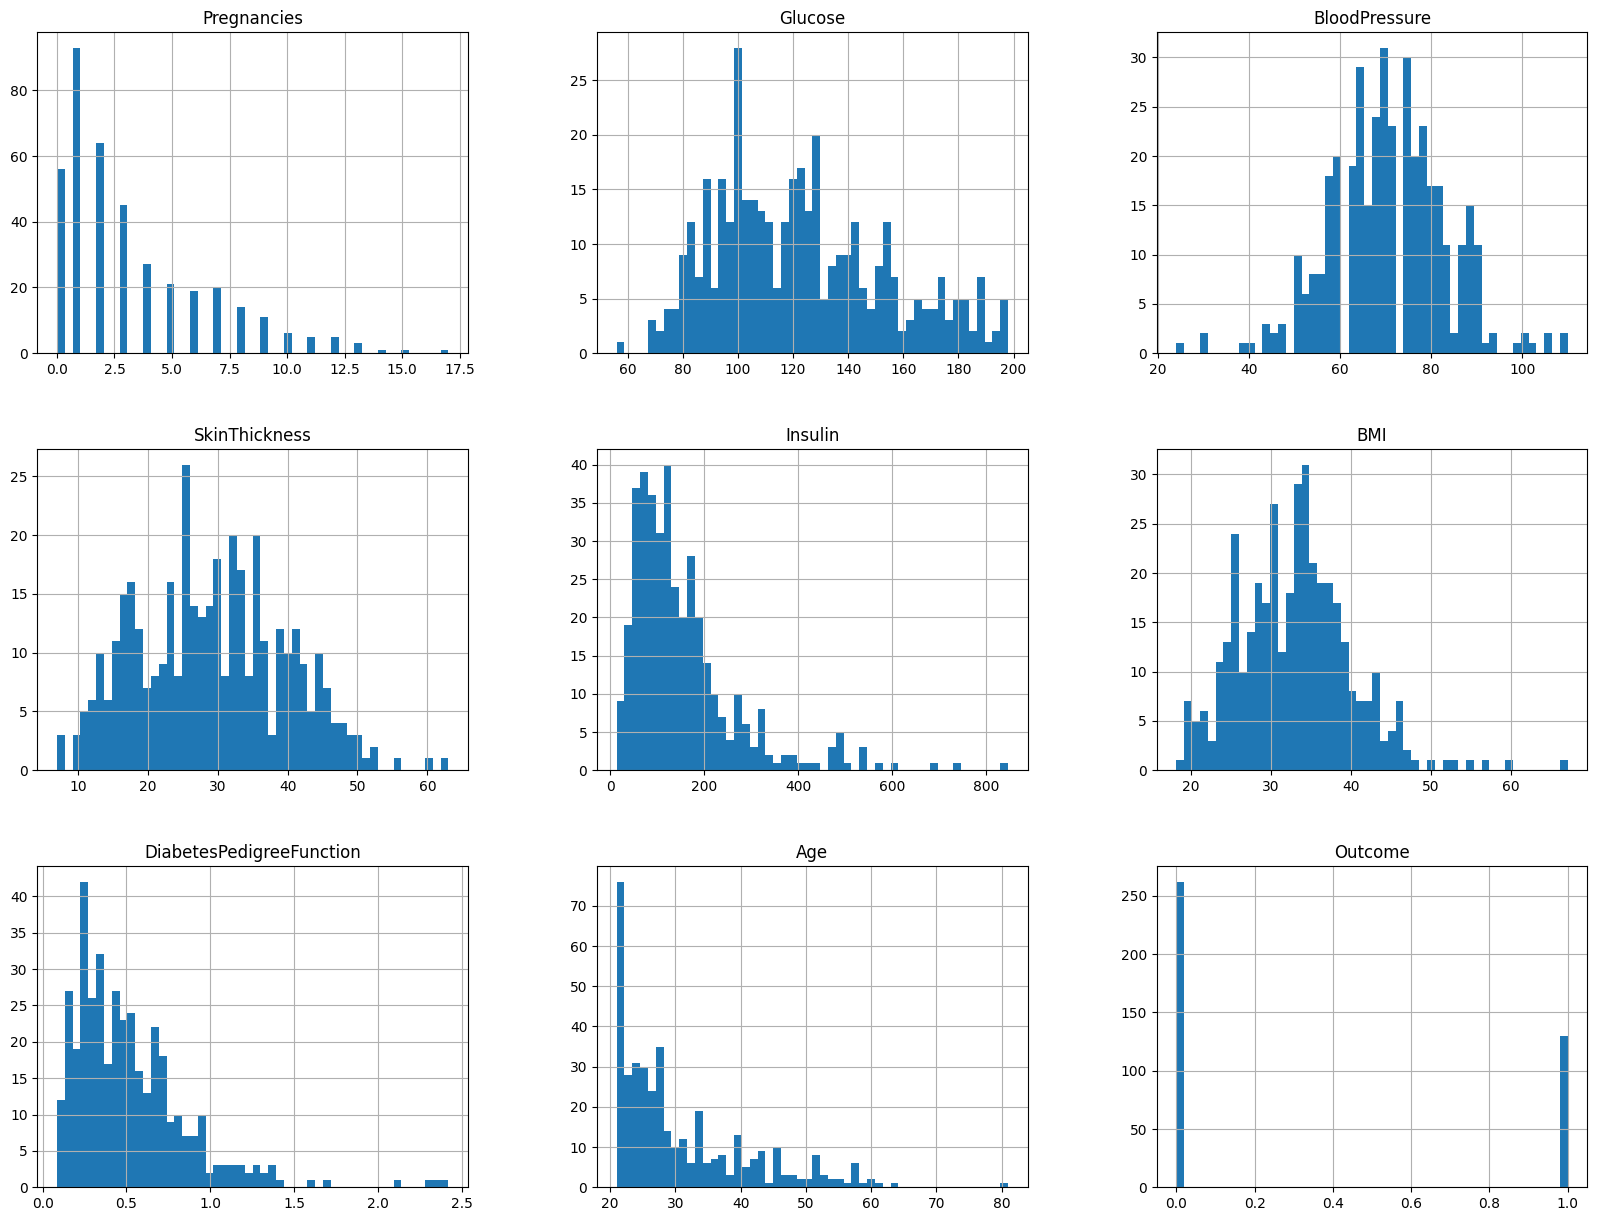

In [51]:
pima_all.hist(bins=50, figsize=(20, 15))
plt.show()

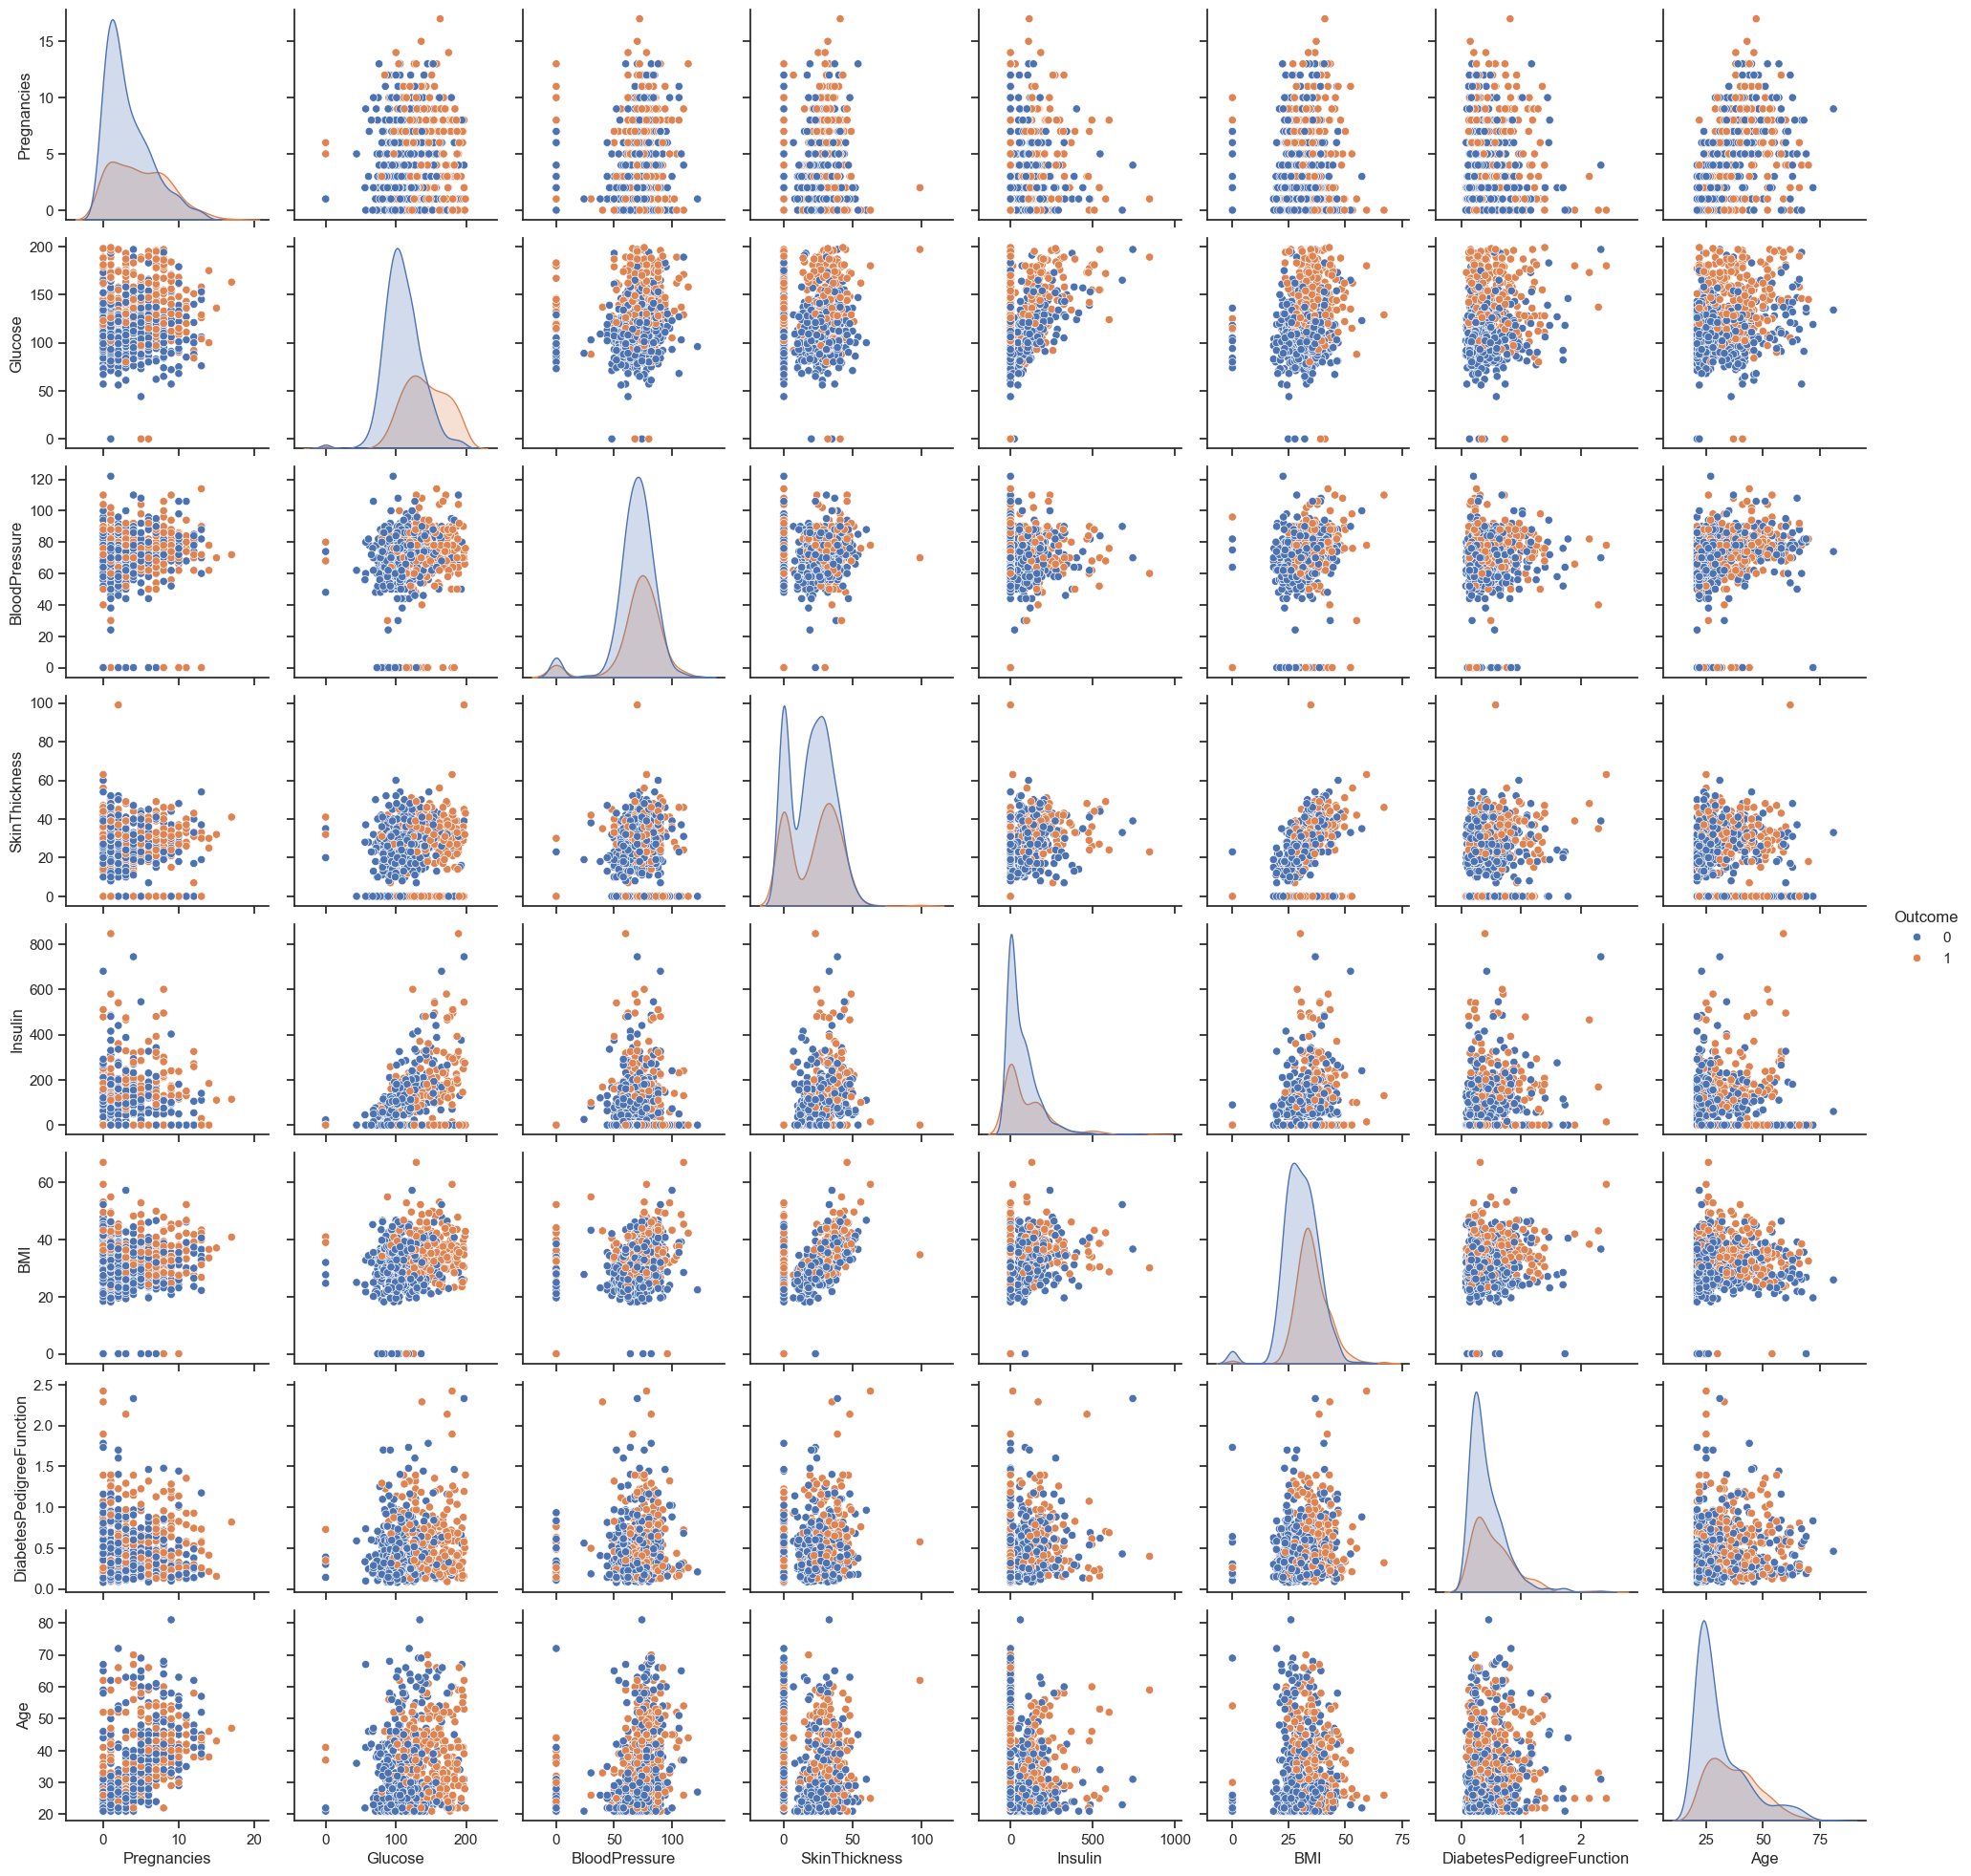

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pima = pd.read_csv('diabetes.csv')
sns.set(style="ticks")
sns.pairplot(pima, hue="Outcome", diag_kind="kde")
plt.show()

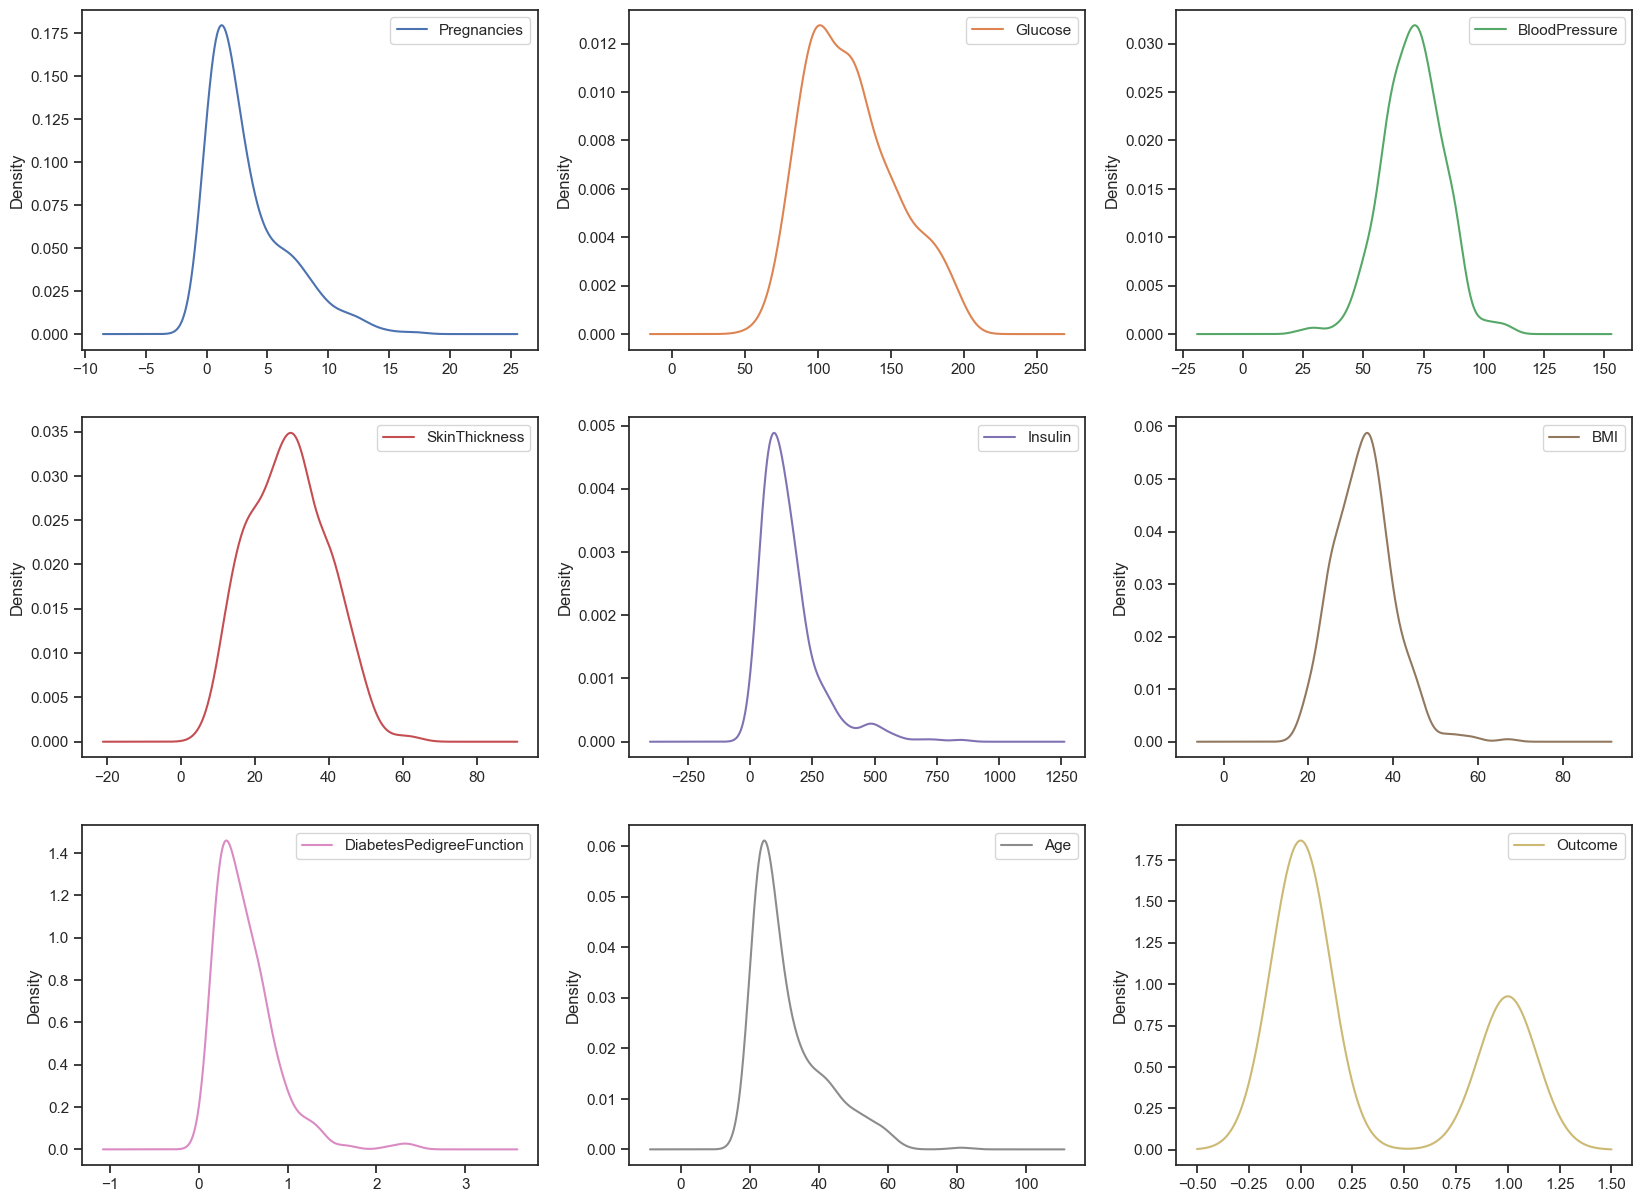

In [53]:
# Density plots for all attributes to visualize the distribution of each attribute
pima_all.plot(kind='density', subplots=True, layout=(3,3), figsize=(20, 15), sharex=False)
plt.show()

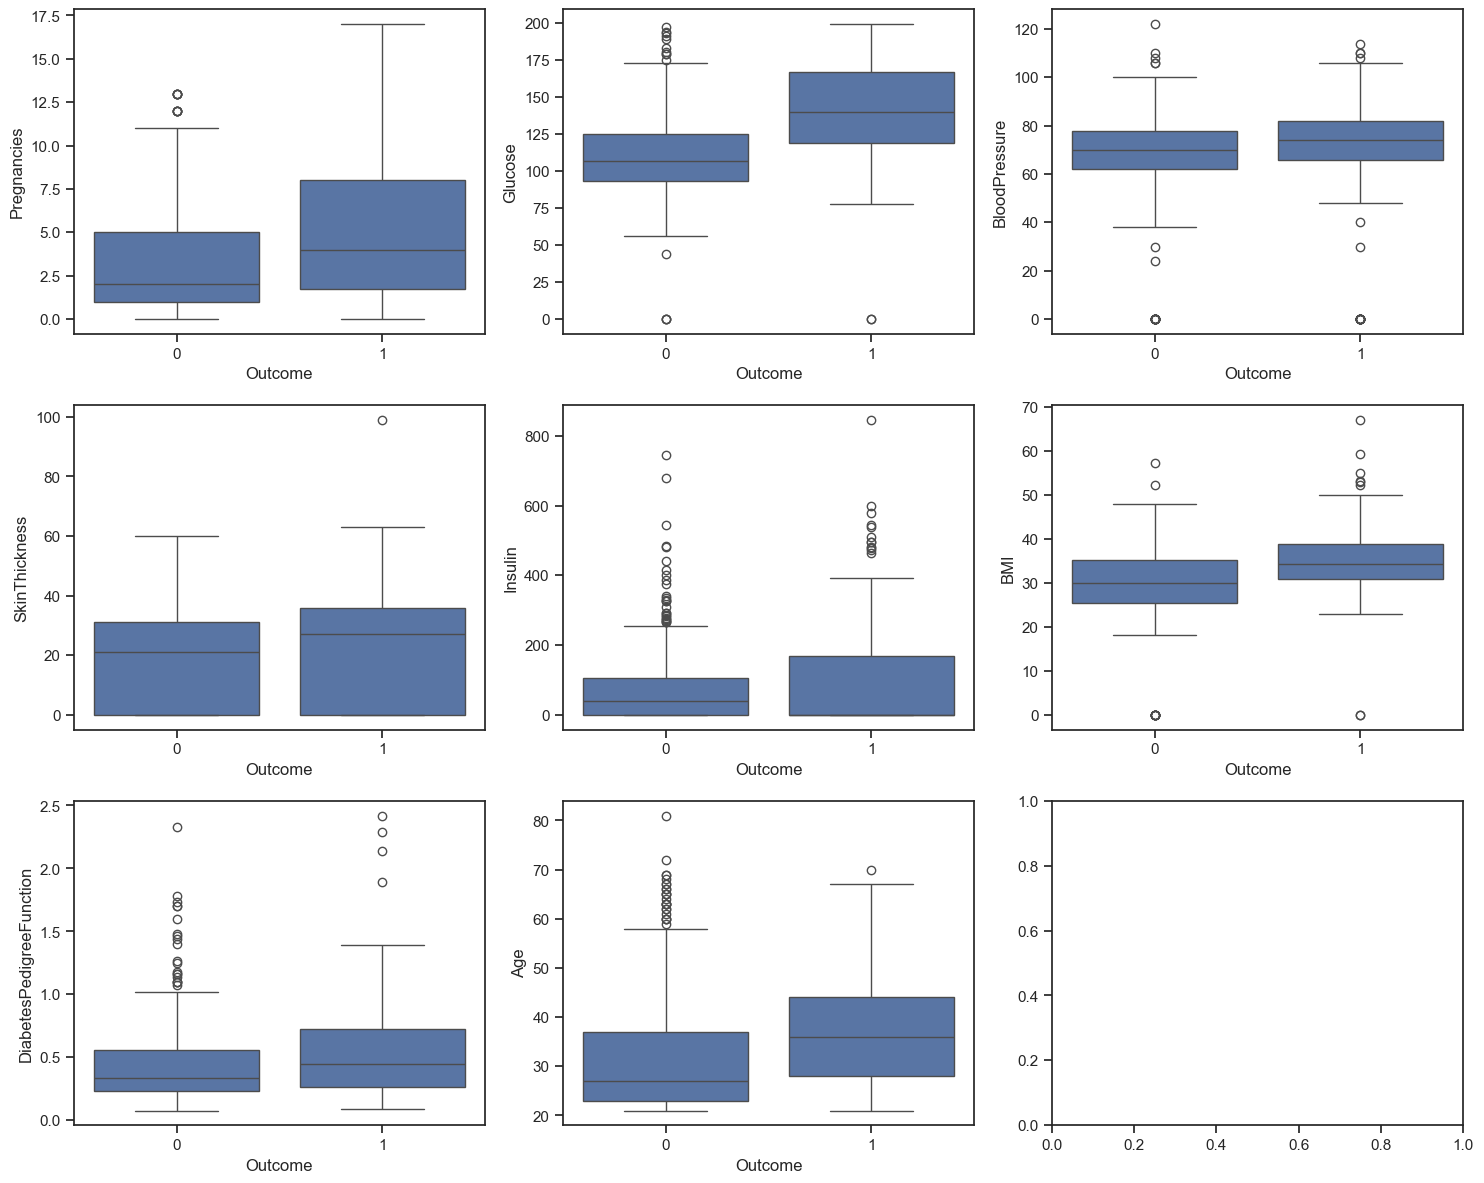

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pima = pd.read_csv('diabetes.csv')
features = pima.columns[:-1]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=pima, ax=axes[i])
plt.tight_layout()
plt.show()

C:\Users\Varhun\AppData\Local\Temp\ipykernel_21996\252403689.py:7: FutureWarning: 
,
,Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
,
,  sns.boxplot(
,C:\Users\Varhun\AppData\Local\Temp\ipykernel_21996\252403689.py:7: FutureWarning: 
,
,Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
,
,  sns.boxplot(
,C:\Users\Varhun\AppData\Local\Temp\ipykernel_21996\252403689.py:7: FutureWarning: 
,
,Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
,
,  sns.boxplot(
,C:\Users\Varhun\AppData\Local\Temp\ipykernel_21996\252403689.py:7: FutureWarning: 
,
,Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

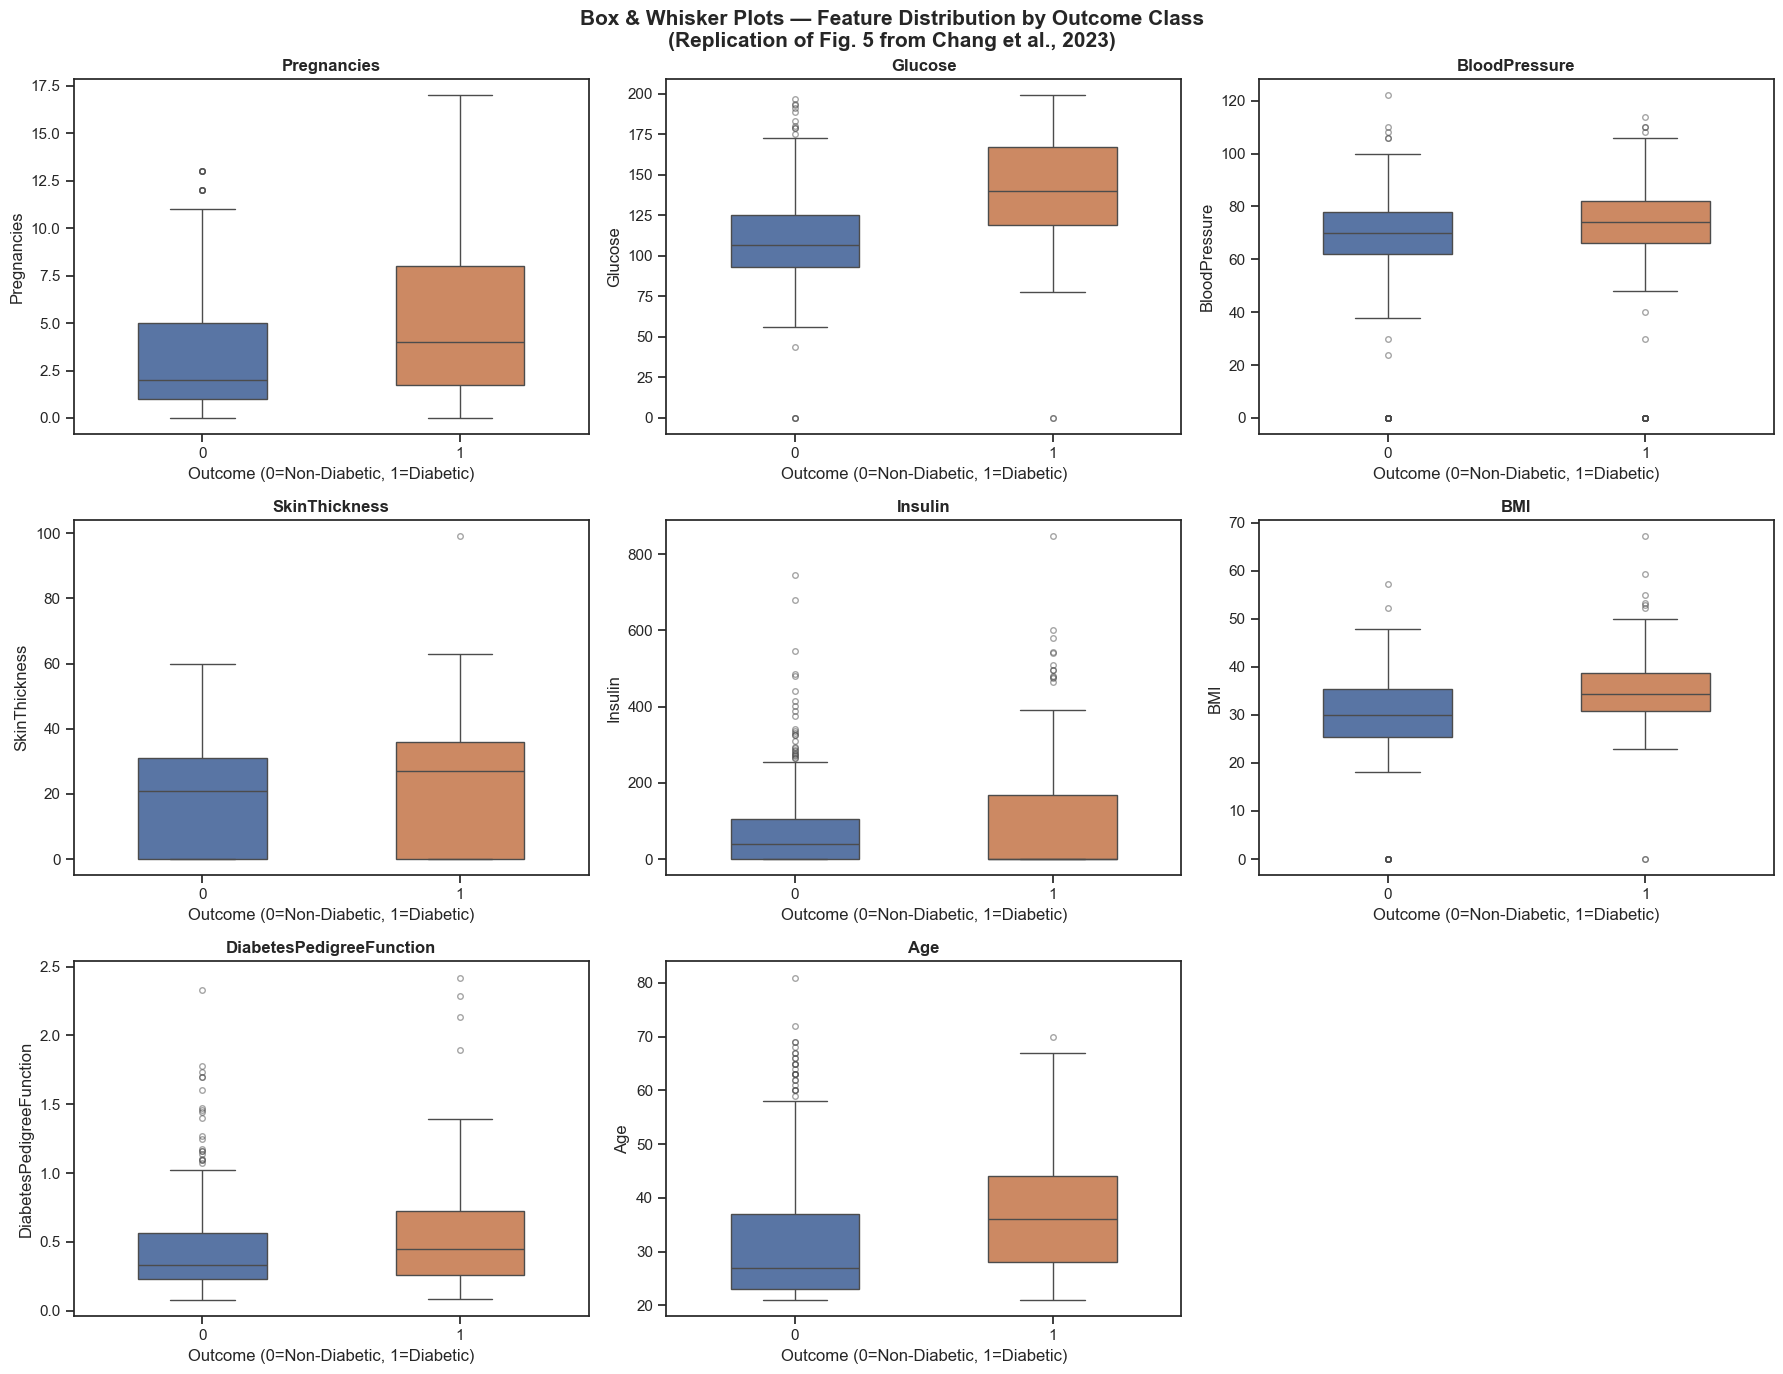

In [55]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

palette = {'0': '#4C72B0', '1': '#DD8452'}

for i, feat in enumerate(features):
    sns.boxplot(
        data=pima, x='Outcome', y=feat,
        palette=palette, ax=axes[i],
        width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
    axes[i].set_ylabel(feat)

axes[-1].axis('off')  # hide last empty subplot
fig.suptitle('Box & Whisker Plots — Feature Distribution by Outcome Class\n(Replication of Fig. 5 from Chang et al., 2023)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

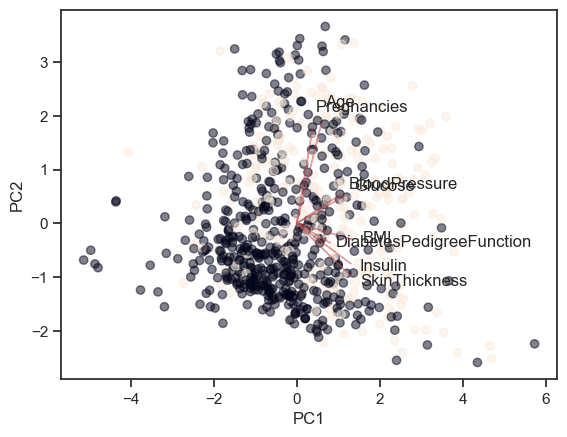

In [56]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
pima = pd.read_csv('diabetes.csv')
X = pima.drop('Outcome', axis=1)
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X_std)
plt.scatter(components[:, 0], components[:, 1], c=pima['Outcome'], alpha=0.5)
for i, feature in enumerate(X.columns):
    plt.arrow(0, 0, pca.components_[0, i]*3, pca.components_[1, i]*3, color='r', alpha=0.5)
    plt.text(pca.components_[0, i]*3.5, pca.components_[1, i]*3.5, feature)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
#principal component analysis

In [57]:
#Skew of attributes distributions
skew = pima_all.skew(axis=1, numeric_only=True)
skew

3      0.711041
4      1.339072
6      0.631051
8      2.414030
13     2.756485
         ...   
753    2.391400
755    0.620941
760    1.315786
763    1.228541
765    0.907577
Length: 392, dtype: float64

Bell shape curve: Blood Pressure
Right-Skewed: Age, Insulin, Pregnancies, Diabetes Pedigree Function
Short IQR: insulin, Diabetes Pedigree Function, Blood Pressure and BMI
At least 75% of the women:
are 25 years old or older
have BMI nearly 30 kg/m2
have insulin level 100 or more
have 1 or more pregnancies
have glucose level of 100 mg/dL or more
have blood pressure of 60 mmHg or more

In [58]:
# Correlation between the different characteristics. Closer to 1 better is the correlation.

corr_matrix_pearson = pima_all.corr(method='pearson',numeric_only=True)
corr_matrix_pearson

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.198291,0.213355,0.093209,0.078984,-0.025347,0.007562,0.679608,0.256566
Glucose,0.198291,1.000000,0.210027,0.198856,0.581223,0.209516,0.140180,0.343641,0.515703
BloodPressure,0.213355,0.210027,1.000000,0.232571,0.098512,0.304403,-0.015971,0.300039,0.192673
SkinThickness,0.093209,0.198856,0.232571,1.000000,0.182199,0.664355,0.160499,0.167761,0.255936
Insulin,0.078984,0.581223,0.098512,0.182199,1.000000,0.226397,0.135906,0.217082,0.301429
BMI,-0.025347,0.209516,0.304403,0.664355,0.226397,1.000000,0.158771,0.069814,0.270118
DiabetesPedigreeFunction,0.007562,0.140180,-0.015971,0.160499,0.135906,0.158771,1.000000,0.085029,0.209330
Age,0.679608,0.343641,0.300039,0.167761,0.217082,0.069814,0.085029,1.000000,0.350804
Outcome,0.256566,0.515703,0.192673,0.255936,0.301429,0.270118,0.209330,0.350804,1.000000


There are no strong correlation between the features. The 'strongest' ones are the following (as expected):
Age x pregnancies (0.68) - Older women tend to have higher number of pregnancies
Glucose x insulin (0.58)
Glucose x outcome (0.52) - Women that have higher level of glucose tend to have higher level of insulin and have DM
Skin fold thickness x BMI (0.66) - Women with higher skin fold thickness value have higher BMI (and probably are overweight/obese)
Negative correlation:
BMI x Pregnancies (-0.025)
Blood Pressure x Diabetes Pedigree Function (-0.016)

<Axes: >

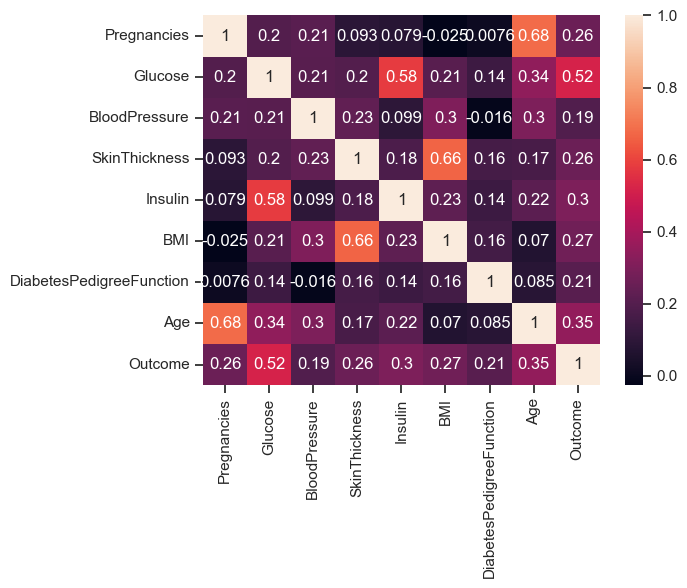

In [59]:
sns.heatmap(corr_matrix_pearson, annot = True)

**---------------------------------------**

Logistic Regression

In [60]:
#1st Iteration - 8 variables
var1=["Pregnancies", "Glucose","BloodPressure","SkinThickness","Insulin", "BMI","DiabetesPedigreeFunction", "Age"]
X=pima_all[var1]
y=pima_all.Outcome

In [61]:
## Defining the model and assigning Y (Dependent) and X (Independent Variables)
logit_model=sm.Logit(y,X)

## Fitting the model and publishing the results
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
,         Current function value: 0.563677
,         Iterations 6
,                           Logit Regression Results                           
,==============================================================================
,Dep. Variable:                Outcome   No. Observations:                  392
,Model:                          Logit   Df Residuals:                      384
,Method:                           MLE   Df Model:                            7
,Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.1128
,Time:                        21:57:59   Log-Likelihood:                -220.96
,converged:                       True   LL-Null:                       -249.05
,Covariance Type:            nonrobust   LLR p-value:                 8.717e-10
,============================================================================================
,                               coef    std err          z      P>|z|      [0.025 

his model can explain 56% of the variation in dependent variable. SkinThickness, BMI, Diabetes Pedigree Function, Age, and Insulin are attributes to be eliminated in the next model. as variables that influence the outcome should have a p-value less than 0.05.

In [62]:
#2nd Iteration - 3 variables
var2=["Pregnancies", "Glucose","BloodPressure"]
X=pima_all[var2]
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
,         Current function value: 0.574607
,         Iterations 5
,                           Logit Regression Results                           
,==============================================================================
,Dep. Variable:                Outcome   No. Observations:                  392
,Model:                          Logit   Df Residuals:                      389
,Method:                           MLE   Df Model:                            2
,Date:                Wed, 06 May 2026   Pseudo R-squ.:                 0.09558
,Time:                        21:57:59   Log-Likelihood:                -225.25
,converged:                       True   LL-Null:                       -249.05
,Covariance Type:            nonrobust   LLR p-value:                 4.597e-11
,=================================================================================
,                    coef    std err          z      P>|z|      [0.025      0.975]
,---------

This model can explain 57% of the variation in dependent variable. All the variables show a p-value < 0.005

In [63]:
logreg = LogisticRegression()
var2=["Pregnancies", "Glucose","BloodPressure"]
X=pima_all[var2]
y=pima_all.Outcome
logreg.fit(X,y)

## Defining the y_pred variable for the predicting values.
y_pred=logreg.predict(X)

## Calculating the precision of the model
print(classification_report(y,y_pred))

              precision    recall  f1-score   support
,
,           0       0.80      0.87      0.83       262
,           1       0.68      0.55      0.61       130
,
,    accuracy                           0.77       392
,   macro avg       0.74      0.71      0.72       392
,weighted avg       0.76      0.77      0.76       392
,


The model precision of model #2 (3 variables) is 77%.

Classifier

In [64]:
inputs = pima_all[['Glucose', 'Insulin', 'SkinThickness', 'BMI', 'Age']]
outputs = pima_all['Outcome']
knn = nei.KNeighborsClassifier(n_neighbors=5)
knn.fit(inputs, outputs)

KNeighborsClassifier()

In [65]:
(knn.predict(inputs) == outputs).sum()

322

From 392, 322 got correct outcome predicted.

In [66]:
#Split the train set - 1/3 is to test

inputs_train, inputs_test, outputs_train, outputs_test = mod.train_test_split(inputs,outputs, test_size =0.33)
knn = nei.KNeighborsClassifier(n_neighbors=5)
knn.fit(inputs_train, outputs_train)

KNeighborsClassifier()

In [67]:
(knn.predict(inputs_test) == outputs_test).sum()

89

In [68]:
#Count how many women are Positive (1) and Negative (0) for diabetes in the test set

outputs_test.value_counts()

Outcome
0    85
1    45
Name: count, dtype: int64

Check classification accuracy with knn = 5

In [69]:
outputs_pred = knn.predict(inputs_test)
accuracy = metrics.accuracy_score(outputs_test, outputs_pred)
accuracy

0.6846153846153846

In [70]:
# 10-fold cross-validation with knn = 5

scores = cross_val_score (knn, inputs, outputs, cv =10, scoring = 'accuracy')
scores

array([0.725     , 0.8       , 0.64102564, 0.61538462, 0.64102564,
       0.74358974, 0.66666667, 0.82051282, 0.76923077, 0.79487179])

In [71]:
scores.mean()

0.7217307692307692

Optimal value of k

In [72]:
k_range = range(1,41)
k_scores = []
for k in k_range:
    knn = nei.KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score (knn, inputs, outputs, cv = 10, scoring = 'accuracy')
    k_scores.append(scores.mean())
k_scores

[0.7222435897435897,
 0.7396794871794872,
 0.7297435897435897,
 0.7369871794871795,
 0.7217307692307692,
 0.7396153846153846,
 0.7522435897435897,
 0.7523717948717948,
 0.7499358974358974,
 0.7625641025641026,
 0.7702564102564102,
 0.7625641025641026,
 0.7652564102564102,
 0.7574358974358975,
 0.7473717948717948,
 0.7472435897435897,
 0.7575,
 0.7549358974358974,
 0.752371794871795,
 0.7575641025641026,
 0.755,
 0.7498076923076923,
 0.7472435897435897,
 0.7548717948717949,
 0.7472435897435898,
 0.7497435897435898,
 0.7471794871794872,
 0.7523076923076923,
 0.7471794871794872,
 0.7523076923076923,
 0.7548717948717949,
 0.7574358974358975,
 0.7548717948717949,
 0.7523717948717948,
 0.7574358974358975,
 0.7574358974358975,
 0.7676282051282051,
 0.7625641025641026,
 0.76,
 0.7599358974358974]

Text(0, 0.5, 'Cross-validation accuracy')

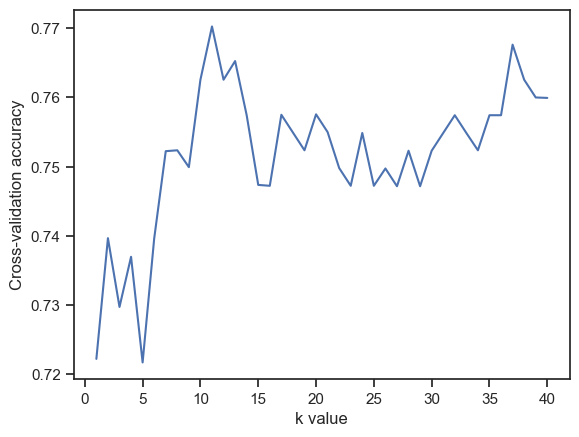

In [73]:
#Visualise best k number

plt.plot(k_range, k_scores)
plt.xlabel ('k value')
plt.ylabel('Cross-validation accuracy')

In [74]:
# Optimal value for k is 10

knn = nei.KNeighborsClassifier(n_neighbors=10)
knn.fit(inputs_train, outputs_train)

KNeighborsClassifier(n_neighbors=10)

In [75]:
(knn.predict(inputs_test) == outputs_test).sum()

95

In [76]:
outputs_pred = knn.predict(inputs_test)
accuracy = metrics.accuracy_score(outputs_test, outputs_pred)
accuracy

0.7307692307692307

In [77]:
# 10-fold cross-validation with knn = 3

scores = cross_val_score (knn, inputs, outputs, cv =10, scoring = 'accuracy')
scores #accuracy scores arrays (from 61.5% to 84.6%)

array([0.8       , 0.8       , 0.69230769, 0.61538462, 0.69230769,
       0.84615385, 0.71794872, 0.87179487, 0.79487179, 0.79487179])

Cross Validation

Recursive feature elimination with cross-validation

In [78]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=1)
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lg = LogisticRegression()
rfecv = RFECV (estimator=lg,step=1, cv=skf, scoring='accuracy')
rfecv.fit(inputs, outputs)

RFECV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
      estimator=LogisticRegression(), scoring='accuracy')

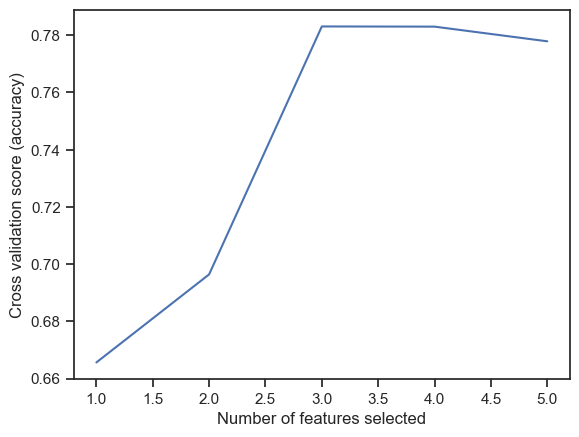

In [79]:
import matplotlib.pyplot as plt

# Use cv_results_['mean_test_score'] instead of grid_scores_
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (accuracy)")
plt.show()

#Optical number of features (=5) more suitable to predict the outcome

In [80]:
feature_names = pima_all.columns[:10]
feature_names

Index(['Pregnancies', 'Glucose', 'Glucose Result', 'BloodPressure',
       'Percentile skin thickness', 'SkinThickness', 'Insulin', 'BMI',
       'Nutritional Status', 'DiabetesPedigreeFunction'],
      dtype='object')

In [81]:
X = pima_all[feature_names]

In [82]:
new_features = list(filter(lambda x: x[1],zip(feature_names, rfecv.support_)))
new_features

[('Pregnancies', True),
 ('BloodPressure', True),
 ('Percentile skin thickness', True)]

In [83]:
new_inputs = pima_all[['Pregnancies','Glucose', 'BloodPressure','SkinThickness']]
knn = nei.KNeighborsClassifier(n_neighbors=10)
knn.fit(new_inputs, outputs)

KNeighborsClassifier(n_neighbors=10)

In [84]:
(knn.predict(new_inputs) == outputs).sum()

303

In [85]:
new_inputs_train, new_inputs_test, outputs_train, outputs_test = mod.train_test_split(new_inputs,outputs, test_size =0.33)

In [86]:
knn.fit(new_inputs_train, outputs_train)

KNeighborsClassifier(n_neighbors=10)

In [87]:
(knn.predict(new_inputs_test) == outputs_test).sum()

88

In [88]:
outputs_pred_new_inputs = knn.predict(new_inputs_test)
accuracy = metrics.accuracy_score(outputs_test, outputs_pred_new_inputs)
accuracy

0.676923076923077

In [89]:
scores = cross_val_score (knn, new_inputs, outputs, cv =10, scoring = 'accuracy')
scores.mean()

0.7551923076923076

Logistic Regression

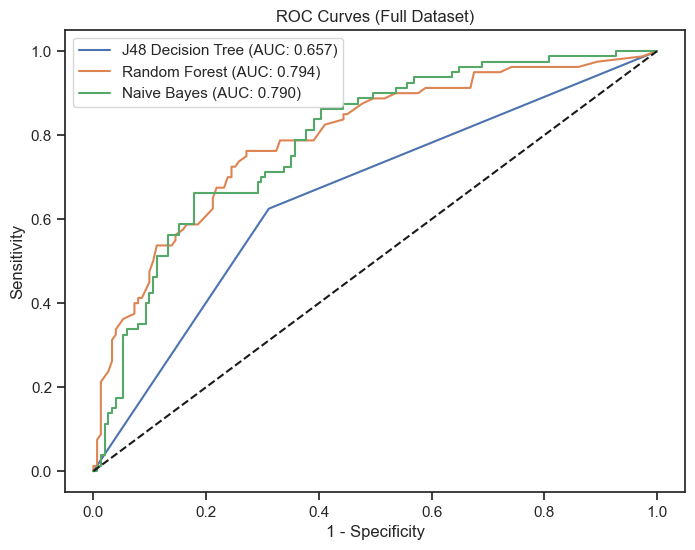

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

X = pima.drop('Outcome', axis=1)
y = pima['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    'J48 Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB()
}

plt.figure(figsize=(8, 6))
for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC: {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curves (Full Dataset)')
plt.legend()
plt.show()

In [91]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        results.append({
            'MODEL': name,
            'Accuracy': f"{accuracy_score(y_test, y_pred)*100:.2f}%",
            'Precision': f"{precision_score(y_test, y_pred)*100:.2f}%",
            'Sensitivity': f"{recall_score(y_test, y_pred)*100:.2f}%",
            'F-Score': f"{f1_score(y_test, y_pred)*100:.2f}%",
            'AUC': f"{roc_auc_score(y_test, probs)*100:.2f}%"
        })
    return pd.DataFrame(results)

# Table 13: Full Data
print("Table 13: Results (Full Dataset)")
print(get_metrics(pima.drop('Outcome', axis=1), pima['Outcome']))

# Table 14: 3-Factor
print("\nTable 14: Results (3-Factor: Gluc, BMI, Age)")
print(get_metrics(pima[['Glucose', 'BMI', 'Age']], pima['Outcome']))

Table 13: Results (Full Dataset)
,               MODEL Accuracy Precision Sensitivity F-Score     AUC
,0  J48 Decision Tree   68.40%    53.54%      66.25%  59.22%  67.89%
,1      Random Forest   74.46%    63.29%      62.50%  62.89%  80.11%
,2        Naive Bayes   74.46%    62.35%      66.25%  64.24%  79.05%
,
,Table 14: Results (3-Factor: Gluc, BMI, Age)
,               MODEL Accuracy Precision Sensitivity F-Score     AUC
,0  J48 Decision Tree   65.80%    50.60%      52.50%  51.53%  62.67%
,1      Random Forest   71.43%    58.75%      58.75%  58.75%  77.80%
,2        Naive Bayes   73.16%    61.84%      58.75%  60.26%  76.95%


Best Performer :- Random Forest

In [92]:
lg = LogisticRegression()
lg_accuracy = cross_val_score(lg,inputs,outputs,cv=10,scoring='accuracy')
lg_accuracy.mean()

0.7828846153846154

Logistic Regression has a better average accuracy score than knn.

In [93]:
lg.fit(inputs_train,outputs_train)

LogisticRegression()

In [94]:
outputs_pred=lg.predict(inputs_test)
accuracy_lg = metrics.accuracy_score(outputs_test, outputs_pred)
accuracy_lg

0.6384615384615384

Naive Bayes

In [95]:
mnb = MultinomialNB()
mnb.fit(inputs_train, outputs_train)
out_pred = mnb.predict(inputs_test)
accuracy_mnb = accuracy_score(outputs_test, out_pred)
accuracy_mnb

0.6230769230769231

Confusion Matrix

In [96]:
conf_mtx_nb = metrics.confusion_matrix(outputs_test, out_pred)
conf_mtx_nb

array([[61, 23],
       [26, 20]], dtype=int64)

In [97]:
conf_mtx_new_features = metrics.confusion_matrix(outputs_test, outputs_pred_new_inputs)
conf_mtx_new_features

array([[76,  8],
       [34, 12]], dtype=int64)

In reality, 46 women in the sample have DM, and 84 women do not.

Naive Bayes: Out of those 130 cases, the classifier predicted "yes" 30 times, and "no" 100 times.

New Features and k = 10 : Out of those 130 cases, the classifier predicted "yes" 43 times, and "no" 87 times.

Precision

In [98]:
precision_nb = metrics.precision_score(outputs_test, out_pred)
precision_nb

0.46511627906976744

In [99]:
precision_new_features = metrics.precision_score(outputs_test,outputs_pred_new_inputs)
precision_new_features

0.6

In [100]:
recall = metrics.recall_score(outputs_test, out_pred)
recall

0.43478260869565216

In [101]:
recall_new_features = metrics.recall_score(outputs_test,outputs_pred_new_inputs)
recall_new_features

0.2608695652173913

The "new features" and k = 10 model can identify 43.5% of the time the individuals who are diabetic in the test set.

In [102]:
class_rep = classification_report(outputs_test, out_pred)
class_rep

'              precision    recall  f1-score   support\n\n           0       0.70      0.73      0.71        84\n           1       0.47      0.43      0.45        46\n\n    accuracy                           0.62       130\n   macro avg       0.58      0.58      0.58       130\nweighted avg       0.62      0.62      0.62       130\n'

In [103]:
out_pred_prob = mnb.predict_proba(inputs_test)[:,1]
out_pred_prob

array([5.29605381e-03, 9.23214511e-01, 6.92332273e-05, 7.55287902e-03,
       4.98237701e-01, 2.01747232e-02, 3.82355296e-04, 1.88167823e-02,
       9.84539052e-01, 9.97671219e-01, 9.83850553e-01, 5.03522803e-06,
       4.85968457e-03, 1.71414995e-04, 1.29719979e-02, 4.11267350e-03,
       1.08776928e-06, 1.13060645e-02, 1.55986807e-05, 8.60603208e-01,
       6.85233953e-03, 6.45003879e-02, 1.00000000e+00, 9.73644169e-01,
       1.91664240e-02, 6.99789872e-05, 4.84687371e-04, 1.75646550e-03,
       2.04837440e-03, 1.00000000e+00, 3.00717435e-04, 4.15234017e-02,
       4.47021066e-04, 3.93352871e-01, 8.44937448e-04, 1.04234450e-03,
       1.36825230e-05, 1.00000000e+00, 4.38459317e-04, 8.55897500e-01,
       1.88916812e-02, 7.93755332e-02, 3.29807591e-03, 8.25436589e-03,
       1.96039062e-05, 9.95540747e-01, 6.57488344e-01, 6.46090505e-01,
       9.19726327e-02, 9.74240736e-01, 1.72515346e-01, 9.99999987e-01,
       1.00000000e+00, 7.11919510e-01, 6.70286256e-01, 4.29541772e-03,
      

## K-means clustering plots

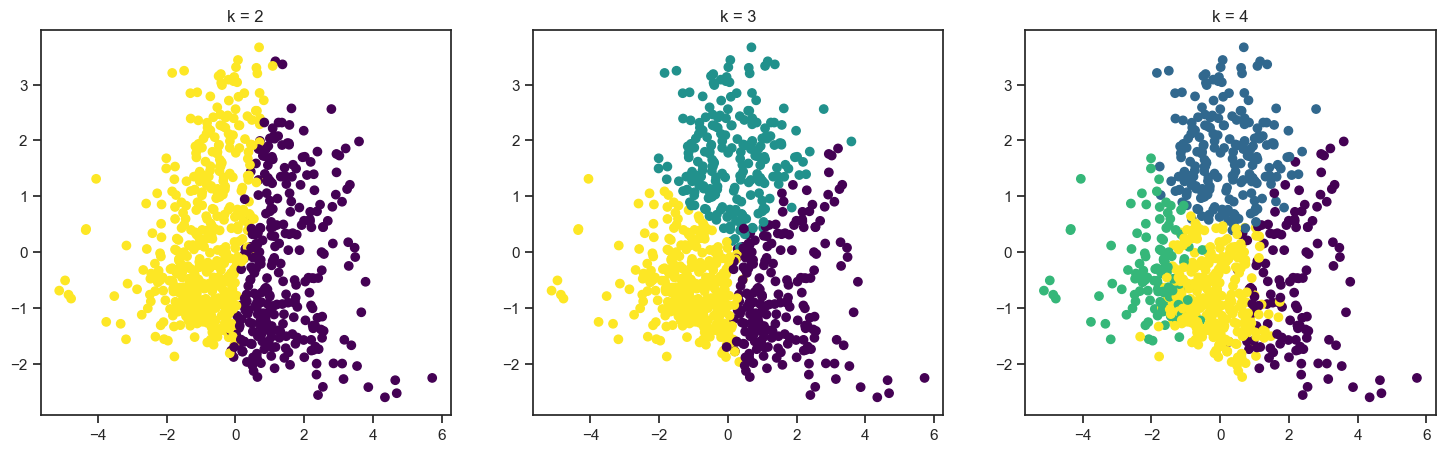

In [104]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pima = pd.read_csv('diabetes.csv')
X = StandardScaler().fit_transform(pima.drop('Outcome', axis=1))
pca_data = PCA(n_components=2).fit_transform(X)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, k in enumerate([2, 3, 4]):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    axes[i].scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans.labels_, cmap='viridis')
    axes[i].set_title(f'k = {k}')
plt.show()

XGBoost Classification

In [105]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Data Prep
X = pima.drop('Outcome', axis=1)
y = pima['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# XGBoost Classifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred = xgb_clf.predict(X_test)
y_probs = xgb_clf.predict_proba(X_test)[:, 1]

# Display Classification Metrics (Tables 13-15)
print("--- XGBoost Classification Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Sensitivity (Recall): {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred)*100:.2f}%")
print(f"AUC Score: {roc_auc_score(y_test, y_probs)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- XGBoost Classification Performance ---
,Accuracy: 71.43%
,Precision: 57.29%
,Sensitivity (Recall): 68.75%
,F1-Score: 62.50%
,AUC Score: 78.44%
,
,Classification Report:
,               precision    recall  f1-score   support
,
,           0       0.81      0.73      0.77       151
,           1       0.57      0.69      0.62        80
,
,    accuracy                           0.71       231
,   macro avg       0.69      0.71      0.70       231
,weighted avg       0.73      0.71      0.72       231
,


c:\Users\Varhun\Downloads\pds10\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [21:58:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
,Parameters: { "use_label_encoder" } are not used.
,
,  bst.update(dtrain, iteration=i, fobj=obj)


Statistical Regression Metrics

In [106]:
import statsmodels.api as sm

# Adding a constant for statsmodels
X_stat = sm.add_constant(X)
logit_model = sm.Logit(y, X_stat)
result = logit_model.fit()

# Detailed statistical output
print("\n--- Detailed Statistical Model (Logistic Regression) ---")
print(result.summary())

# Specifically extracting requested metrics
print(f"LL-Null: {result.llnull:.4f}")
print(f"LLR p-value: {result.llr_pvalue:.4e}")
print(f"DF Model: {result.df_model}")


Optimization terminated successfully.
,         Current function value: 0.470993
,         Iterations 6
,
,--- Detailed Statistical Model (Logistic Regression) ---
,                           Logit Regression Results                           
,==============================================================================
,Dep. Variable:                Outcome   No. Observations:                  768
,Model:                          Logit   Df Residuals:                      759
,Method:                           MLE   Df Model:                            8
,Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.2718
,Time:                        21:58:06   Log-Likelihood:                -361.72
,converged:                       True   LL-Null:                       -496.74
,Covariance Type:            nonrobust   LLR p-value:                 9.652e-54
,============================================================================================
,                     

XGBoost Regression

In [107]:
from sklearn.metrics import r2_score

# Predicting Glucose concentration
X_reg = pima.drop(['Glucose', 'Outcome'], axis=1)
y_reg = pima['Glucose']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

xgb_reg = xgb.XGBRegressor(random_state=42)
xgb_reg.fit(X_train_r, y_train_r)
y_pred_r = xgb_reg.predict(X_test_r)

# SST, SSR, SSE Calculation
y_mean = np.mean(y_test_r)
sst = np.sum((y_test_r - y_mean)**2) # Total Sum of Squares
sse = np.sum((y_test_r - y_pred_r)**2) # Sum of Squared Errors
ssr = sst - sse # Regression Sum of Squares (Explained)
r_sq = r2_score(y_test_r, y_pred_r)

# IQR Calculation
q1, q3 = np.percentile(y_reg, [25, 75])
iqr = q3 - q1

print("\n--- XGBoost Regression Metrics (Target: Glucose) ---")
print(f"R-Square: {r_sq:.4f}")
print(f"SST: {sst:.2f}")
print(f"SSR: {ssr:.2f}")
print(f"SSE: {sse:.2f}")
print(f"IQR: {iqr:.2f}")



,--- XGBoost Regression Metrics (Target: Glucose) ---
,R-Square: -0.0474
,SST: 223488.00
,SSR: -10601.45
,SSE: 234089.45
,IQR: 41.25


Visuval Representation

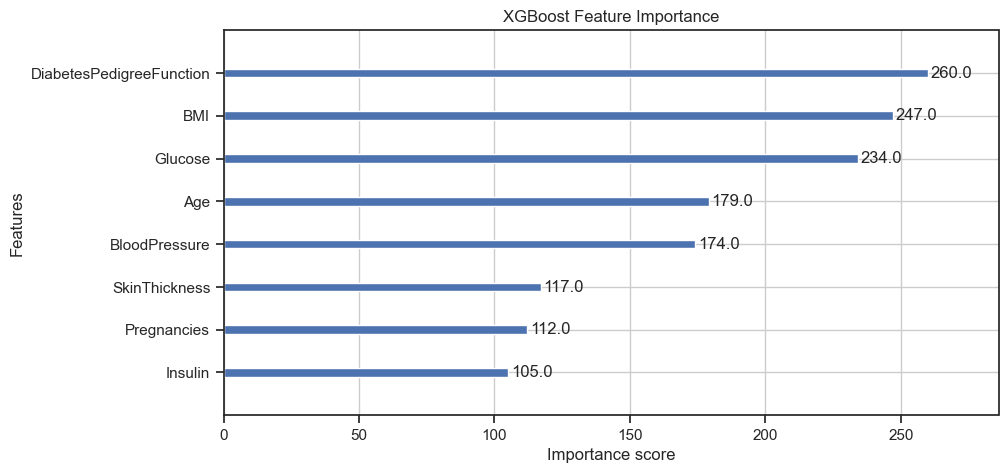

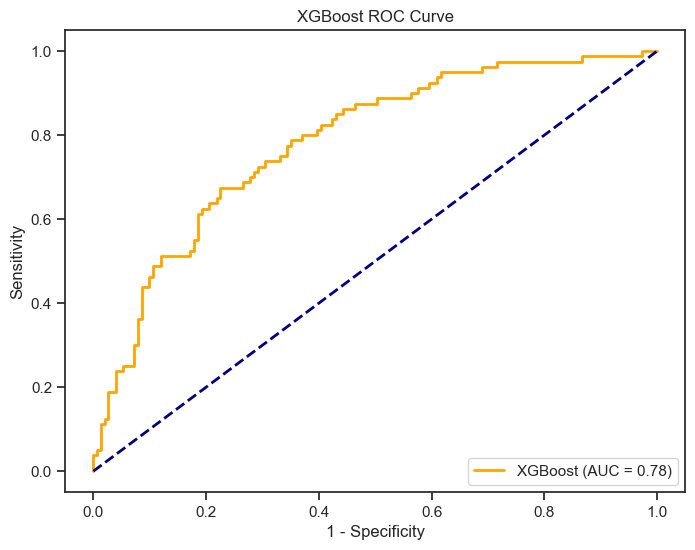

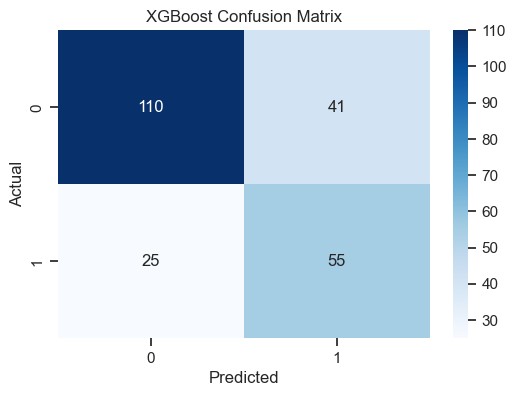

In [108]:
# 1. Feature Importance (Replicating Figure 8)
plt.figure(figsize=(10, 5))
xgb.plot_importance(xgb_clf, importance_type='weight', ax=plt.gca())
plt.title("XGBoost Feature Importance")
plt.show()

# 2. ROC Curve (Replicating Figure 9)
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_probs):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('XGBoost ROC Curve')
plt.legend(loc="lower right")
plt.show()

# 3. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()


In [109]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno

# ── Scikit-Learn: Preprocessing ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Scikit-Learn: Models ─────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression

# ── Scikit-Learn: Metrics ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Feature Selection ────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel

# ── Imbalanced Dataset Handling ──────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Plot Styling ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

SEED = 42
np.random.seed(SEED)

print("✅ All imports successful!")

✅ All imports successful!


## SMOTE Learning

Class counts BEFORE SMOTE: {0: 262, 1: 130}
,Class counts AFTER  SMOTE: {0: 262, 1: 262}


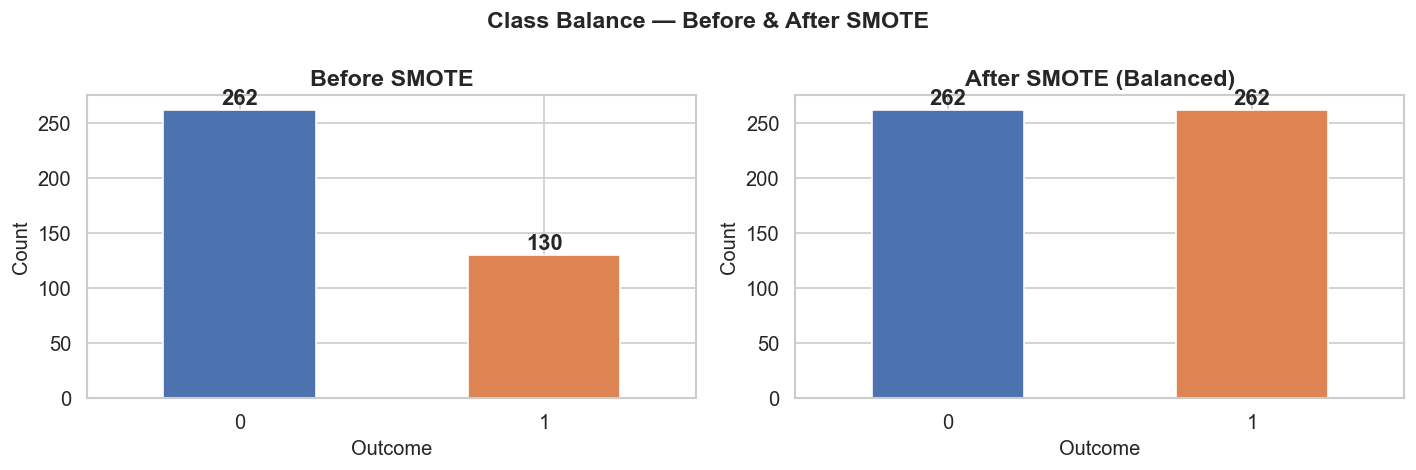

In [110]:
X = pima_all.drop('Outcome', axis=1)
y = pima_all['Outcome']
print(f"Class counts BEFORE SMOTE: {dict(y.value_counts())}")
X = pd.get_dummies(pima_all.drop('Outcome',axis=1),drop_first=True)
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Class counts AFTER  SMOTE: {dict(pd.Series(y_resampled).value_counts())}")

# Visualise balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y.value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'],
                      edgecolor='white', rot=0)
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_xlabel('Outcome'); axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

pd.Series(y_resampled).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'], edgecolor='white', rot=0)
axes[1].set_title('After SMOTE (Balanced)', fontweight='bold')
axes[1].set_xlabel('Outcome'); axes[1].set_ylabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

fig.suptitle('Class Balance — Before & After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance In Random Forrest

📊 Feature Importance Scores (Random Forest):
,                                   Feature  Importance
,                                   Glucose    0.199629
,                                   Insulin    0.120607
,                                       Age    0.119604
,                                       BMI    0.095323
,                  DiabetesPedigreeFunction    0.091451
,                             SkinThickness    0.066272
,                             BloodPressure    0.058480
,                               Pregnancies    0.049765
,                     Glucose Result_Normal    0.047659
,                           BMI_Class_Obese    0.027118
,                  Nutritional Status_Obese    0.024546
,       Percentile skin thickness_19 >P95th    0.017817
,Percentile skin thickness_11 P50th - P75th    0.016163
,Percentile skin thickness_15 P85th - P90th    0.010957
,                      BMI_Class_Overweight    0.008309
,             Nutritional Status_Overweight    0.008288
,Pe

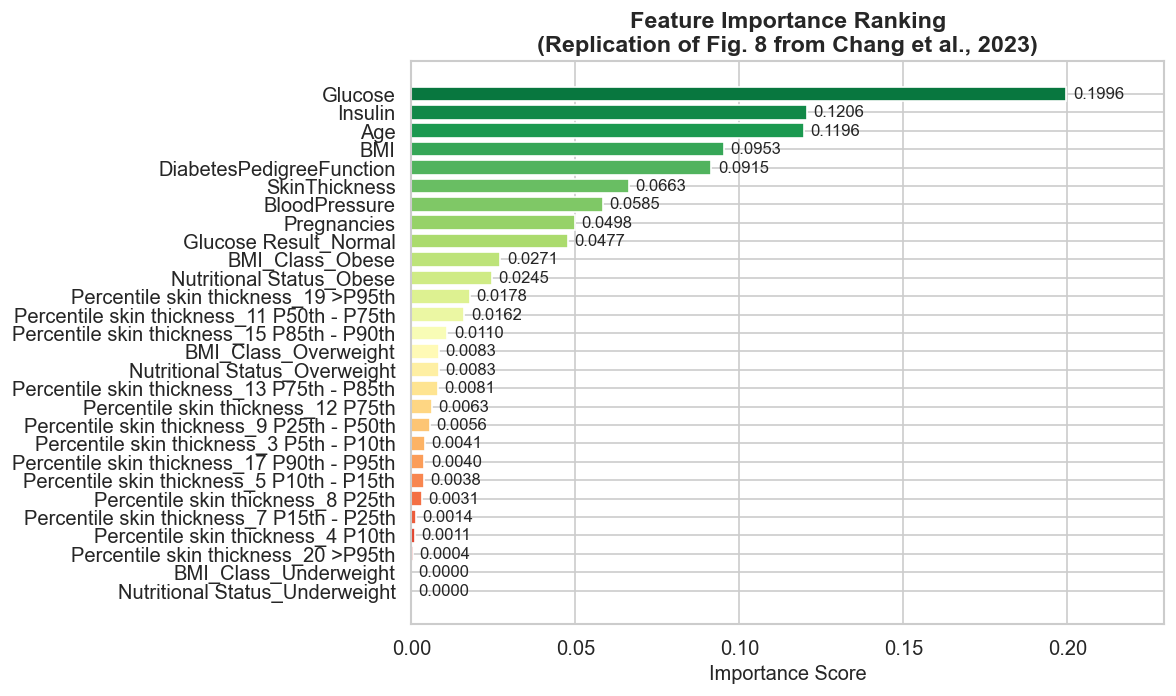

In [111]:
# Feature importance via Random Forest
rf_for_importance = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_for_importance.fit(X_resampled, y_resampled)

importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_for_importance.feature_importances_
}).sort_values('Importance', ascending=False)

print("📊 Feature Importance Scores (Random Forest):")
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    importance_df['Feature'], importance_df['Importance'],
    color=sns.color_palette('RdYlGn_r', len(importance_df)),
    edgecolor='white'
)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance Ranking\n(Replication of Fig. 8 from Chang et al., 2023)',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0, importance_df['Importance'].max() * 1.15)
plt.tight_layout()
plt.show()

In [112]:
# Use SMOTE-balanced data — 70/30 split (matches paper methodology)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.30,
    random_state=SEED,
    stratify=y_resampled
)

# RobustScaler is better than StandardScaler for outlier-heavy data
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("✅ Train/Test Split:")
print(f"   Training set : {X_train_s.shape[0]} samples")
print(f"   Testing  set : {X_test_s.shape[0]} samples")
print(f"   Test size    : {X_test_s.shape[0]/len(X_resampled)*100:.1f}%")

✅ Train/Test Split:
,   Training set : 366 samples
,   Testing  set : 158 samples
,   Test size    : 30.2%


Evaluation Function

In [113]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, ax_cm=None, ax_roc=None, color='blue'):
    """Train, predict and return a full metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)  * 100
    prec = precision_score(y_te, y_pred) * 100
    rec  = recall_score(y_te, y_pred)    * 100
    spec = (confusion_matrix(y_te, y_pred)[0,0] /
            confusion_matrix(y_te, y_pred)[0,:].sum()) * 100
    f1   = f1_score(y_te, y_pred)        * 100
    auc  = roc_auc_score(y_te, y_prob)   * 100

    # Confusion Matrix plot
    if ax_cm is not None:
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Non-Diabetic','Diabetic'])
        disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
        ax_cm.set_title(f'{name}\nConfusion Matrix', fontweight='bold')

    # ROC curve data (for combined plot)
    fpr, tpr, _ = roc_curve(y_te, y_prob)

    return {
        'Model'      : name,
        'Accuracy'   : acc,
        'Precision'  : prec,
        'Sensitivity': rec,
        'Specificity': spec,
        'F-Score'    : f1,
        'AUC'        : auc,
        'fpr'        : fpr,
        'tpr'        : tpr,
        'model_obj'  : model
    }

print("✅ evaluate_model() helper function defined.")

✅ evaluate_model() helper function defined.


## 🌳 CELL 17 — Model 1: J48 Decision Tree (Replicating Paper)

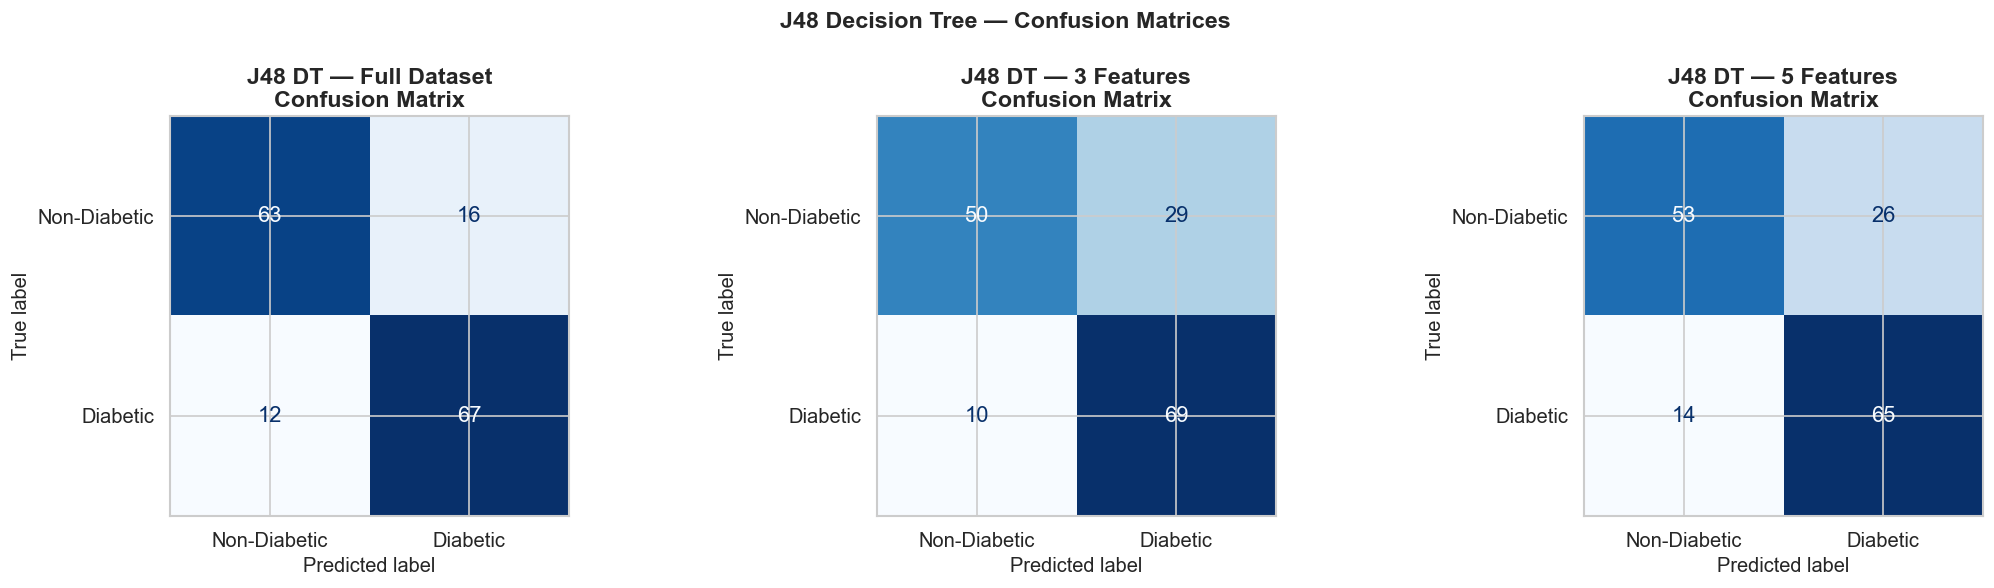


,📊 J48 Decision Tree Results:


,Accuracy,Precision,Sensitivity,Specificity,F-Score,AUC
Model,,,,,,
J48 DT — Full Dataset,82.28,80.72,84.81,79.75,82.72,86.45
J48 DT — 3 Features,75.32,70.41,87.34,63.29,77.97,81.54
J48 DT — 5 Features,74.68,71.43,82.28,67.09,76.47,81.19


In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dt_configs = [
    ('J48 DT — Full Dataset',  X_train_s, y_train, X_test_s, y_test),
    ('J48 DT — 3 Features',
     X_train_s[:, [1,5,7]], y_train,
     X_test_s[:,  [1,5,7]], y_test),
    ('J48 DT — 5 Features',
     X_train_s[:, [1,5,7,4,3]], y_train,
     X_test_s[:,  [1,5,7,4,3]], y_test),
]

dt_results = []
for i, (name, Xtr, ytr, Xte, yte) in enumerate(dt_configs):
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=SEED)
    res = evaluate_model(name, dt, Xtr, ytr, Xte, yte, ax_cm=axes[i])
    dt_results.append(res)

fig.suptitle('J48 Decision Tree — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 J48 Decision Tree Results:")
dt_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['fpr','tpr','model_obj']}
                       for r in dt_results])
display(dt_df.set_index('Model').round(2))

## 🌲 CELL 18 — Model 2: Random Forest

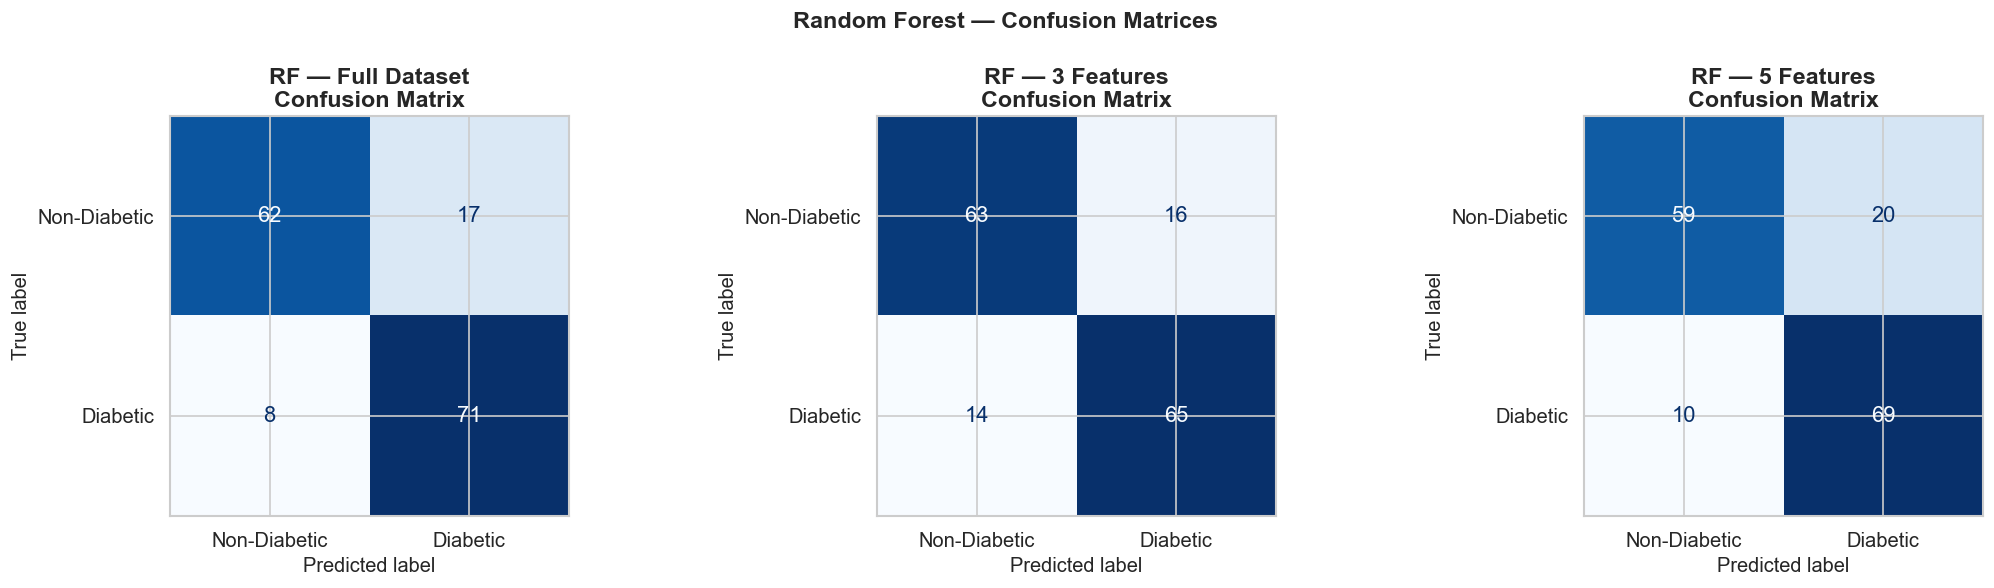


,📊 Random Forest Results:


,Accuracy,Precision,Sensitivity,Specificity,F-Score,AUC
Model,,,,,,
RF — Full Dataset,84.18,80.68,89.87,78.48,85.03,92.21
RF — 3 Features,81.01,80.25,82.28,79.75,81.25,87.51
RF — 5 Features,81.01,77.53,87.34,74.68,82.14,89.59


In [115]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rf_configs = [
    ('RF — Full Dataset',  X_train_s, y_train, X_test_s, y_test),
    ('RF — 3 Features',
     X_train_s[:, [1,5,7]], y_train,
     X_test_s[:,  [1,5,7]], y_test),
    ('RF — 5 Features',
     X_train_s[:, [1,5,7,4,3]], y_train,
     X_test_s[:,  [1,5,7,4,3]], y_test),
]

rf_results = []
for i, (name, Xtr, ytr, Xte, yte) in enumerate(rf_configs):
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
    res = evaluate_model(name, rf, Xtr, ytr, Xte, yte, ax_cm=axes[i])
    rf_results.append(res)

fig.suptitle('Random Forest — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Random Forest Results:")
rf_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['fpr','tpr','model_obj']}
                       for r in rf_results])
display(rf_df.set_index('Model').round(2))

## 📐 CELL 19 — Model 3: Naïve Bayes

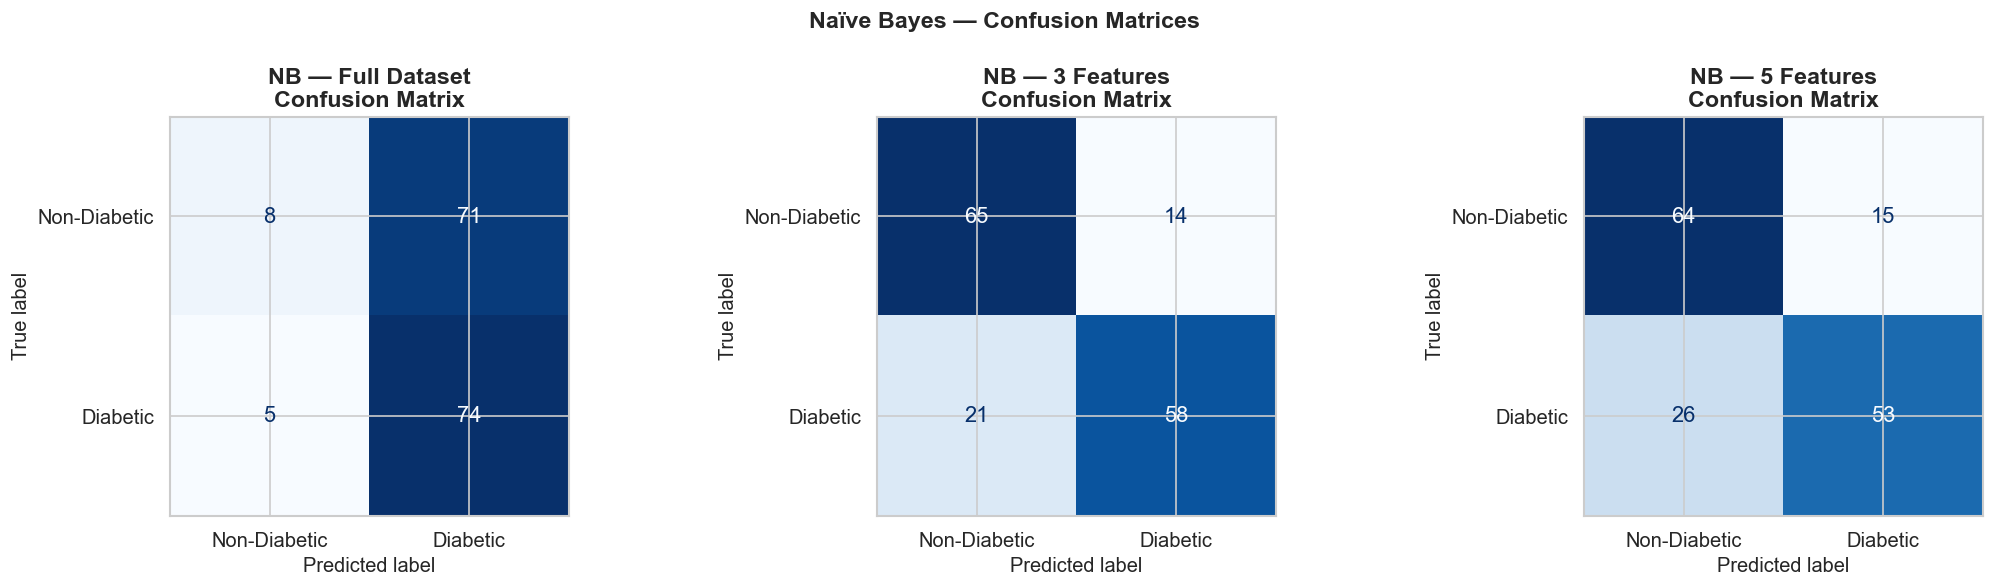


,📊 Naïve Bayes Results:


,Accuracy,Precision,Sensitivity,Specificity,F-Score,AUC
Model,,,,,,
NB — Full Dataset,51.90,51.03,93.67,10.13,66.07,76.52
NB — 3 Features,77.85,80.56,73.42,82.28,76.82,83.74
NB — 5 Features,74.05,77.94,67.09,81.01,72.11,82.42


In [116]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

nb_configs = [
    ('NB — Full Dataset',  X_train_s, y_train, X_test_s, y_test),
    ('NB — 3 Features',
     X_train_s[:, [1,5,7]], y_train,
     X_test_s[:,  [1,5,7]], y_test),
    ('NB — 5 Features',
     X_train_s[:, [1,5,7,4,3]], y_train,
     X_test_s[:,  [1,5,7,4,3]], y_test),
]

nb_results = []
for i, (name, Xtr, ytr, Xte, yte) in enumerate(nb_configs):
    nb = GaussianNB()
    res = evaluate_model(name, nb, Xtr, ytr, Xte, yte, ax_cm=axes[i])
    nb_results.append(res)

fig.suptitle('Naïve Bayes — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Naïve Bayes Results:")
nb_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['fpr','tpr','model_obj']}
                       for r in nb_results])
display(nb_df.set_index('Model').round(2))

## PyCaret

In [117]:
from pycaret.classification import (
    setup, compare_models, pull, create_model,
    tune_model, evaluate_model as pycaret_eval,
    plot_model, finalize_model, predict_model,
    get_config, save_model
)

# PyCaret works on the cleaned (pre-SMOTE) dataframe with Outcome column
pycaret_df = pd.concat(
    [pd.DataFrame(X_resampled, columns=X.columns),
     pd.Series(y_resampled, name='Outcome')],
    axis=1
)

print(f"PyCaret Dataset Shape: {pycaret_df.shape}")

# ── PyCaret Setup ────────────────────────────────────────────────────────────
clf_setup = setup(
    data            = pycaret_df,
    target          = 'Outcome',
    train_size      = 0.70,
    session_id      = SEED,
    normalize       = True,
    normalize_method= 'robust',      # robust to outliers
    transformation  = True,          # power transform for normality
    remove_outliers = False,          # IQR-based outlier removal
    outliers_threshold = 0.05,
    fix_imbalance   = False,         # already balanced via SMOTE
    feature_selection = False,        # automatic feature selection
    n_features_to_select = 0.8,
    fold_strategy   = 'stratifiedkfold',
    fold            = 10,
    verbose         = True
)

print("\n✅ PyCaret setup complete!")

PyCaret Dataset Shape: (524, 29)


,Description,Value
0,Session id,42
1,Target,Outcome
2,Target type,Binary
3,Original data shape,"(524, 29)"
4,Transformed data shape,"(524, 29)"
5,Transformed train set shape,"(366, 29)"
6,Transformed test set shape,"(158, 29)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple



,✅ PyCaret setup complete!


## PyCaret: Compare ALL Models (Main Output)

In [118]:
print("⏳ Running and comparing ALL classifiers... (this may take 2–4 minutes)")
print("   Sorted by Accuracy (10-Fold Stratified Cross Validation)\n")

best_model = compare_models(
    sort        = 'Accuracy',
    n_select    = 1,
    cross_validation = True,
    verbose     = True
)

compare_results = pull()
print("\n📊 Full Leaderboard:")
display(compare_results)

best_model_name = type(best_model).__name__
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy : {compare_results['Accuracy'].iloc[0]*100:.2f}%")
print(f"   AUC      : {compare_results['AUC'].iloc[0]*100:.2f}%")
print(f"   F1       : {compare_results['F1'].iloc[0]*100:.2f}%")

⏳ Running and comparing ALL classifiers... (this may take 2–4 minutes)
,   Sorted by Accuracy (10-Fold Stratified Cross Validation)
,


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8197,0.9004,0.8412,0.8097,0.8229,0.6390,0.6438,0.0150
rf,Random Forest Classifier,0.8170,0.8946,0.8570,0.7972,0.8235,0.6334,0.6403,0.0340
et,Extra Trees Classifier,0.8142,0.9100,0.8468,0.7982,0.8198,0.6278,0.6331,0.0380
catboost,CatBoost Classifier,0.8116,0.8924,0.8406,0.8004,0.8165,0.6226,0.6299,0.8180
xgboost,Extreme Gradient Boosting,0.8063,0.8901,0.8301,0.7964,0.8101,0.6124,0.6181,0.0880
lightgbm,Light Gradient Boosting Machine,0.8035,0.8891,0.8462,0.7877,0.8120,0.6069,0.6156,0.0800
ridge,Ridge Classifier,0.7980,0.8796,0.8304,0.7833,0.8040,0.5959,0.6010,0.0150
gbc,Gradient Boosting Classifier,0.7980,0.8686,0.8246,0.7912,0.8027,0.5958,0.6039,0.0250
lr,Logistic Regression,0.7872,0.8759,0.7977,0.7844,0.7885,0.5739,0.5781,0.4900
knn,K Neighbors Classifier,0.7762,0.8430,0.8307,0.7557,0.7884,0.5517,0.5603,0.3880



,📊 Full Leaderboard:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8197,0.9004,0.8412,0.8097,0.8229,0.6390,0.6438,0.015
rf,Random Forest Classifier,0.8170,0.8946,0.8570,0.7972,0.8235,0.6334,0.6403,0.034
et,Extra Trees Classifier,0.8142,0.9100,0.8468,0.7982,0.8198,0.6278,0.6331,0.038
catboost,CatBoost Classifier,0.8116,0.8924,0.8406,0.8004,0.8165,0.6226,0.6299,0.818
xgboost,Extreme Gradient Boosting,0.8063,0.8901,0.8301,0.7964,0.8101,0.6124,0.6181,0.088
lightgbm,Light Gradient Boosting Machine,0.8035,0.8891,0.8462,0.7877,0.8120,0.6069,0.6156,0.080
ridge,Ridge Classifier,0.7980,0.8796,0.8304,0.7833,0.8040,0.5959,0.6010,0.015
gbc,Gradient Boosting Classifier,0.7980,0.8686,0.8246,0.7912,0.8027,0.5958,0.6039,0.025
lr,Logistic Regression,0.7872,0.8759,0.7977,0.7844,0.7885,0.5739,0.5781,0.490
knn,K Neighbors Classifier,0.7762,0.8430,0.8307,0.7557,0.7884,0.5517,0.5603,0.388



,🏆 Best Model: LinearDiscriminantAnalysis
,   Accuracy : 81.97%
,   AUC      : 90.04%
,   F1       : 82.29%


PyCaret: Tune the Best Model

In [119]:
print("⏳ Tuning hyperparameters of the best model...")

tuned_best = tune_model(
    best_model,
    optimize    = 'Accuracy',
    n_iter      = 50,
    search_library = 'optuna',
    search_algorithm = 'tpe',
    verbose     = False
)

tuned_results = pull()
print("\n📊 Tuned Model Performance (10-Fold CV):")
display(tuned_results)

print(f"\n✅ Tuned {type(tuned_best).__name__} ready!")

⏳ Tuning hyperparameters of the best model...
,
,📊 Tuned Model Performance (10-Fold CV):


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8108,0.8743,0.7778,0.8235,0.8000,0.6208,0.6217
1,0.8108,0.8801,0.7778,0.8235,0.8000,0.6208,0.6217
2,0.8649,0.9649,0.9444,0.8095,0.8718,0.7307,0.7404
3,0.7838,0.8538,0.7895,0.7895,0.7895,0.5673,0.5673
4,0.8649,0.9269,0.9474,0.8182,0.8780,0.7283,0.7382
5,0.7568,0.8421,0.7895,0.7500,0.7692,0.5124,0.5132
6,0.8333,0.9167,0.9444,0.7727,0.8500,0.6667,0.6838
7,0.8889,0.9660,0.8333,0.9375,0.8824,0.7778,0.7826
8,0.8611,0.9352,0.8889,0.8421,0.8649,0.7222,0.7233



,✅ Tuned LinearDiscriminantAnalysis ready!


PyCaret: Confusion Matrix of Best Model

🟦 Confusion Matrix — Best Tuned Model:


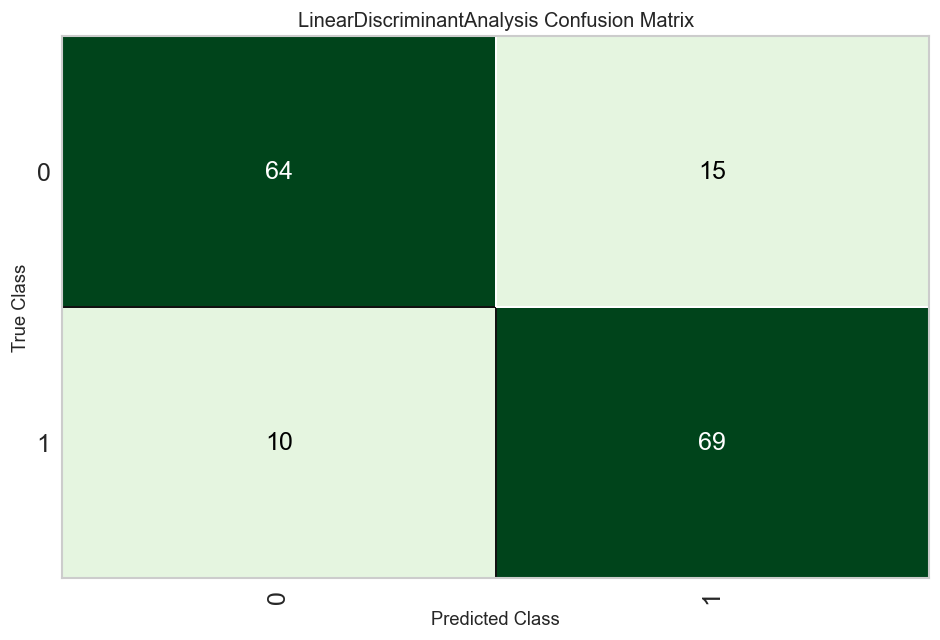

In [120]:
print("🟦 Confusion Matrix — Best Tuned Model:")
plot_model(tuned_best, plot='confusion_matrix')

PyCaret: Class Report & Precision-Recall

📋 Classification Report — Best Tuned Model:


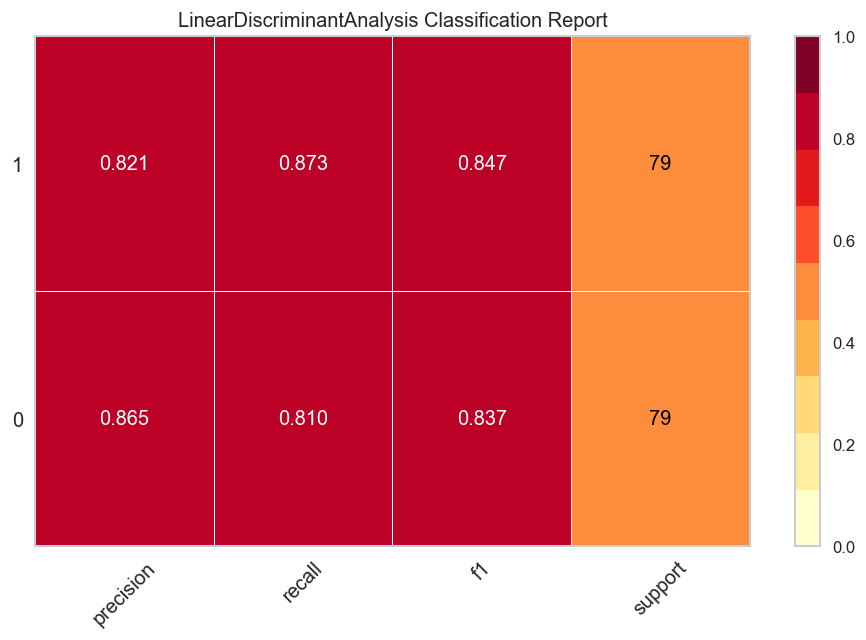

In [121]:
print("📋 Classification Report — Best Tuned Model:")
plot_model(tuned_best, plot='class_report')

PyCaret: Learning Curve

📈 Learning Curve — Best Tuned Model:


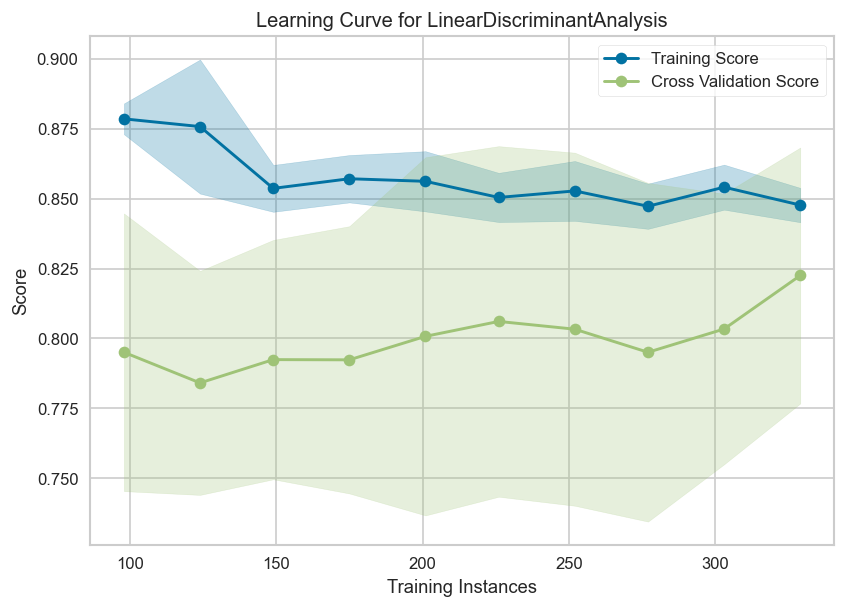

In [122]:
print("📈 Learning Curve — Best Tuned Model:")
plot_model(tuned_best, plot='learning')

## PyCaret: Finalize & Predict on Unseen Data

In [123]:
# Finalize trains on 100% of data
final_model = finalize_model(tuned_best)

# Predict on hold-out test set
predictions = predict_model(tuned_best)
final_results = pull()

print("📊 Final Hold-Out Test Performance:")
display(final_results)

print("\n📋 Sample Predictions (first 10 rows):")
display(predictions[['Glucose','BMI','Age','Outcome','prediction_label','prediction_score']].head(10))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.8418,0.9205,0.8734,0.8214,0.8466,0.6835,0.6849


📊 Final Hold-Out Test Performance:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.8418,0.9205,0.8734,0.8214,0.8466,0.6835,0.6849



,📋 Sample Predictions (first 10 rows):


,Glucose,BMI,Age,Outcome,prediction_label,prediction_score
353,140,24.100000,23,0,0,0.7464
512,124,33.169895,30,1,1,0.9283
285,88,29.900000,23,0,0,0.9504
384,81,46.299999,32,0,0,0.7283
350,56,24.200001,22,0,0,0.9997
81,111,28.400000,29,0,0,0.8530
63,96,21.100000,26,0,0,0.9887
351,95,44.599998,22,0,0,0.8432
260,84,30.400000,21,0,0,0.9764
360,122,35.900002,26,0,0,0.5832


PyCaret Leaderboard Visualisation

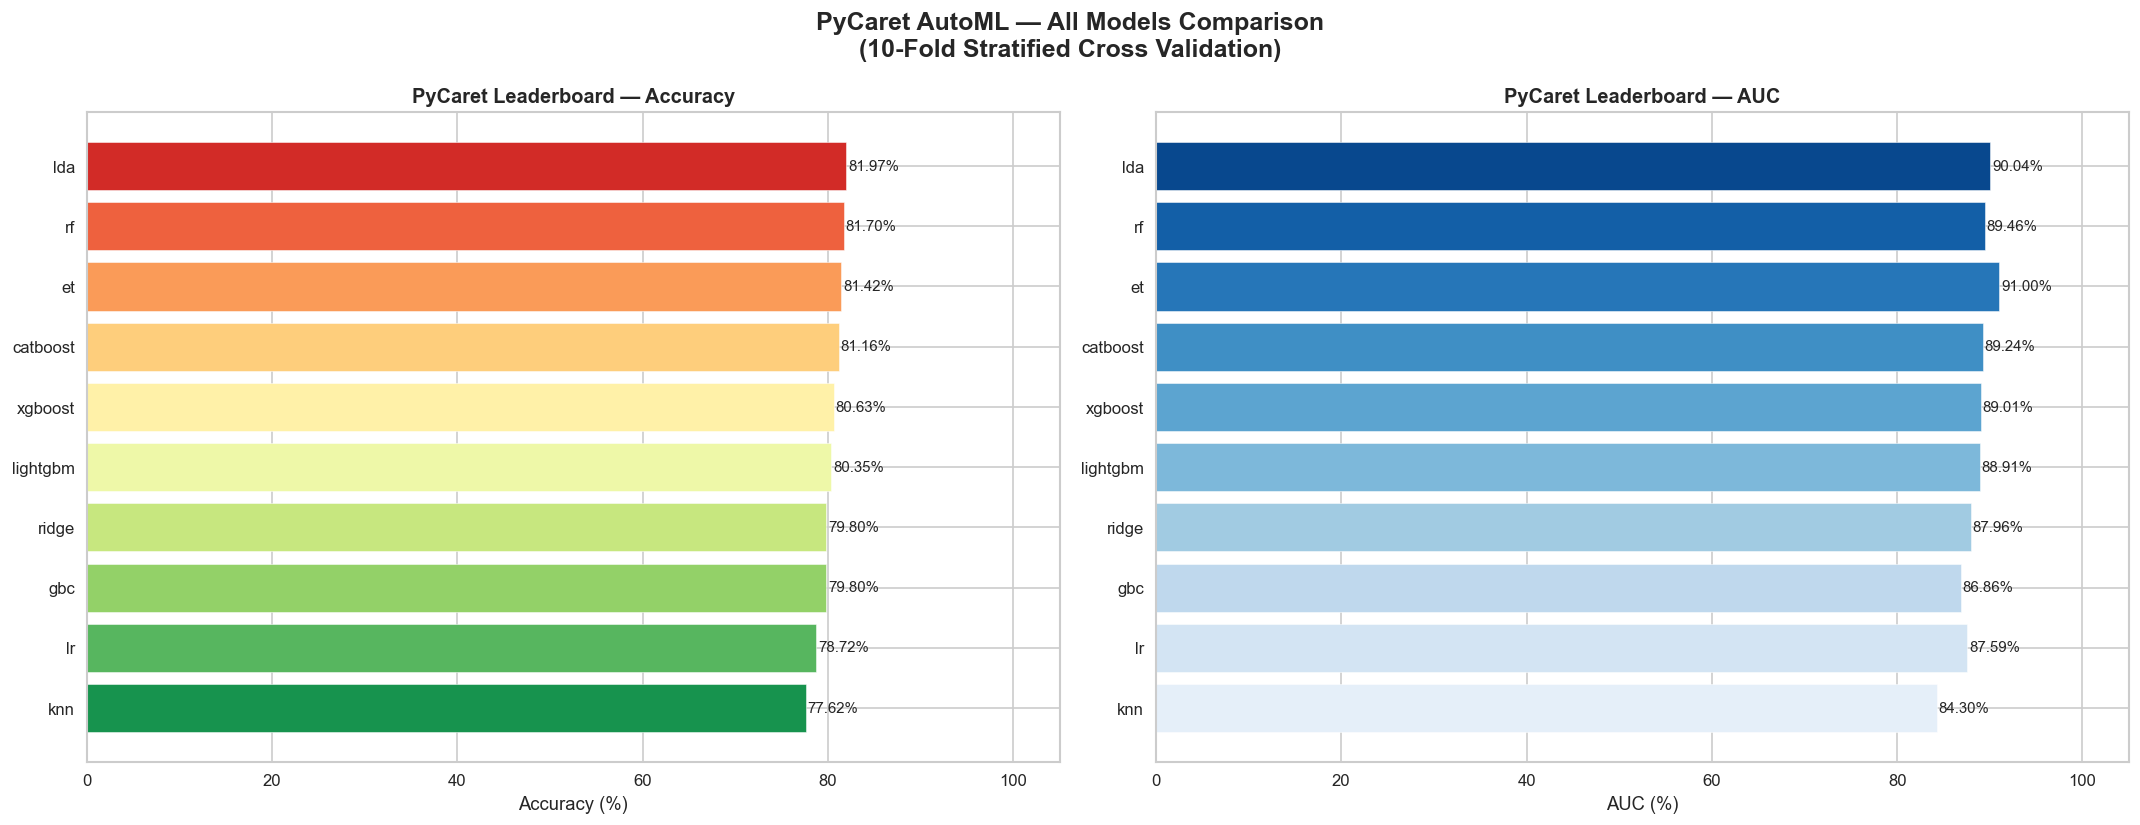

In [124]:
# Plot top-10 models from PyCaret leaderboard
leaderboard = compare_results.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Accuracy
bars = axes[0].barh(
    leaderboard.index, leaderboard['Accuracy'] * 100,
    color=sns.color_palette('RdYlGn', len(leaderboard)), edgecolor='white'
)
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('PyCaret Leaderboard — Accuracy', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, leaderboard['Accuracy']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.2f}%', va='center', fontsize=9)
axes[0].set_xlim(0, 105)

# AUC
bars2 = axes[1].barh(
    leaderboard.index, leaderboard['AUC'] * 100,
    color=sns.color_palette('Blues_r', len(leaderboard)), edgecolor='white'
)
axes[1].set_xlabel('AUC (%)')
axes[1].set_title('PyCaret Leaderboard — AUC', fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars2, leaderboard['AUC']):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.2f}%', va='center', fontsize=9)
axes[1].set_xlim(0, 105)

fig.suptitle('PyCaret AutoML — All Models Comparison\n(10-Fold Stratified Cross Validation)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()